# Регулярные выражения

## Введение

[Тестирование регулярных выражений](https://regex101.com/)

**Регулярное выражение**– это средство работы с текстом, которое позволяет по заданному «паттерну» искать и редактировать искомое слово/строку в тексте.

Регулярные выражения встроены в некоторые языки программирования

Базовая концепция - мы сначала описываем шаблон, а потом находим все подстроки подхдящие под этот шаблон. 

**Зачем вообще возиться с регулярными выражениями?**
* Сравнение с шаблоном: Регулярные выражения отлично помогают определять, соответствует ли строка тому или иному формату – например, телефонному номеру, адресу электронной почты или номеру кредитной карты.
* Замена: При помощи регулярных выражений легко находить и заменять шаблоны в строке.
* Извлечение: При помощи регулярных выражений легко извлекать из шаблона фрагменты информации.
* Портируемость: Почти в любом распространенном языке программирования есть своя библиотека регулярных выражений. Синтаксис в основном стандартизирован, поэтому вам не придется переучиваться регулярным выражениям при переходе на новый язык.
* Четкость и лаконичность: Если вы с регулярными выражениями на «ты», то сможете выполнять весьма нетривиальные операции, написав минимальный объем кода.


## Сырые и f строки 

**Сырые строки**

* ``r`` - сырая строка.

В такой строке отключается экранирование. Это значит, что обратный слеш считается самостоятельным символом. Основное применение сырых строк – работа с регулярными выражениями.

In [82]:
common_string = 'C:\file.txt' # Обычная строка
raw_string = r'C:\file.txt' # Сырая строка

**f-строки**

* ``f`` - сырая строка.

Символы, которые ставятся перед началом строки, и изменяют её поведение, называются префиксами. Ещё один префикс, который понадобится в курсе - это префикс f. Он позволяет форматировать строку, вставляя в неё какие-либо выражения:

In [83]:
a = 1
b = 2
# Добавляем выражения в строку с помощью специального синтаксиса {}
print(f"{a} + {b} = {a + b}")      # 1 + 2 = 3
print(f"5! = {1 * 2 * 3 * 4 * 5}") # 5! = 120

1 + 2 = 3
5! = 120


**Комбинация ``f`` и ``r``**

In [84]:
# Используем 2 префикса одновременно:
raw_f_string = rf'C:\file.txt'
f_raw_string = fr'C:\file.txt'

Никакой разницы в порядке нет

## **Экранирование**

 Если нам нужно использовать какой-то спецсимвол как простой текст, то достаточно поставить перед ним ``\``, как и в обычных строках Python

In [85]:
# Вместо \n мы получим переход на новую строку
print("Переносим\nстроку")

# Вместо \\' получаем вывод \'
# Первый \ экранирует второй \, и он исчезает из вывода 
print("\\'")

Переносим
строку
\'


In [86]:
# Теперь тут выводится строка: Переносим\nстроку
print("Переносим\\nстроку")

# Вместо вывода, который мы ожидали, снова получаем такой: \'
print("\\\'")

# Для того, чтобы исправить эту ситуацию, добавим ещё один обратный слеш!
print("\\\\'")
# И только сейчас мы получим вывод: \\'

Переносим\nстроку
\'
\\'


In [87]:
# Отключаем экранирование всей строки префиксом r:
print(r"Переносим\nстроку")
print(r"\\'")

# Отключаем экранирование каждой последовательности с помощью слешей:
print("Переносим\\nстроку")
print("\\\\'")

Переносим\nстроку
\\'
Переносим\nстроку
\\'


In [88]:

print("\\n")

print("\\\n")

print(r"\\n")

print("\\\\n")

print(fr"\\n")

print("r\\n")

print(f"\\n")

print(rf"\\n")

\n
\

\\n
\\n
\\n
r\n
\n
\\n


In [89]:
from string import printable

print(printable)

0123456789abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~ 	



In [90]:
'<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[]^_`abcdefghijklmnopqrstuvwxyz{|}~абвгдеёжзийклмнопрстуфхцчшщъыьэюяАБВГДЕЁЖЗИЙКЛМНОПРСТУФХЦЧШЩЪЫЬЭЮЯ !"#$%&\'()*+,-./0123456789:;'

'<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[]^_`abcdefghijklmnopqrstuvwxyz{|}~абвгдеёжзийклмнопрстуфхцчшщъыьэюяАБВГДЕЁЖЗИЙКЛМНОПРСТУФХЦЧШЩЪЫЬЭЮЯ !"#$%&\'()*+,-./0123456789:;'

## **Квадратные скобки ``[]``**

``[]`` - это 1 символ!

**(1)** Если мы хотим заменить один из указанных нескольких символов

In [91]:
r'[cr1]'     # Найдёт c, r, и 1
r'[cr]at'    # Найдёт слова cat и rat
r'[12]7[56]' # Найдёт 175, 176, 275, 276

'[12]7[56]'

In [ ]:
r'[cr1]' # Найдёт c, r, и 1
r'[rc1]' # Найдёт c, r, и 1
r'[1cr]' # Найдёт c, r, и 1
r'[1rc]' # Найдёт c, r, и 1
r'[c1r]' # Найдёт c, r, и 1
r'[r1c]' # Найдёт c, r, и 1
# Все регулярные выражения сверху выдают один и тот же результат

**(2)** Если мы хотим заменить один из указанных нескольких символов

In [ ]:
r'[^12]'  # Найдёт всё, кроме 1 и 2
r'[^12]7' # Найдёт все последовательности, что заканчиваются на 7, и не начинаются на 1 и 2

In [92]:
r'[0^]_[0^]' # Найдёт 0_0, 0_^, ^_0, ^_^
r'[\^0]_[\^0]' # Найдёт 0_0, 0_^, ^_0, ^_^

'[\\^0]_[\\^0]'

**(3)** Регулярное выражение в скобках можно сократить вот так:

In [ ]:
r'[0-9]' # То же самое, что и [0123456789]
r'[a-z]' # То же самое, что и [abcdefghijklmnopqrstuvwxyz]
r'[A-Z]' # То же самое, что и [ABCDEFGHIJKLMNOPQRSTUVWXYZ]
r'[а-я]' # То же самое, что и [абвгдежзийклмнопрстуфхцчшщъыьэюя]
r'[А-Я]' # То же самое, что и [АБВГДЕЖЗИЙКЛМНОПРСТУФХЦЧШЩЪЫЬЭЮЯ]

In [ ]:
r'[4-7]' # То же самое, что и [4567]
r'[x-z]' # То же самое, что и [xyz]
r'[B-D]' # То же самое, что и [BCD]
r'[а-ж]' # То же самое, что и [абвгдеж]
r'[П-Т]' # То же самое, что и [ПРСТ]
r'[6-D]' # То же самое, что и [6789:;<=>?@ABCD]

In [ ]:
r'[4-7qwerty]' # То же самое, что и [qwerty4567]
r'[23x-z1]'    # То же самое, что и [xyz123]
r'[B-DF]'      # То же самое, что и [BCDF]

регулярное выражение [21-47] не найдёт числа от 21 до 47, оно будет равносильно выражению [212347]

In [ ]:
r'[4\-7]' # Найдёт 4, -, и 7
r'[-xz]'  # Найдёт -, x, и z
r'[^-xz]' # Найдёт всё, кроме -, x, и z
r'[BD-]'  # Найдёт B, D, и -

**(4)** Исключение символов можно тоже сократить:

In [ ]:
r'[^0-9]' # То же самое, что и [^0123456789]
r'[^a-z]' # То же самое, что и [^abcdefghijklmnopqrstuvwxyz]
r'[^A-Z]' # То же самое, что и [^ABCDEFGHIJKLMNOPQRSTUVWXYZ]
r'[^а-я]' # То же самое, что и [^абвгдежзийклмнопрстуфхцчшщъыьэюя]
r'[^А-Я]' # То же самое, что и [^АБВГДЕЖЗИЙКЛМНОПРСТУФХЦЧШЩЪЫЬЭЮЯ]

In [ ]:
r'[^4-7]' # То же самое, что и [^4567]
r'[^x-z]' # То же самое, что и [^xyz]
r'[^B-D]' # То же самое, что и [^BCD]
r'[^а-ж]' # То же самое, что и [^абвгдеж]
r'[^П-Т]' # То же самое, что и [^ПРСТ]
r'[^6-D]' # То же самое, что и [^6789:;<=>?@ABCD]

In [ ]:
r'[^4-7qwerty]' # То же самое, что и [^qwerty4567]
r'[^23x-z1]'    # То же самое, что и [^xyz123]
r'[^B-DF]'      # То же самое, что и [^BCDF]

**(5)** Можно использовать столько сокращений, сколько мы захотим

In [ ]:
r'[a-zA-Z0-9]' # То же самое, что [abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789]
r'[^э-я1-3]'   # То же самое, что и [^эюя123

**(6)** Если квадратные скобки нужно использовать как обычный текст - достаточно их просто экранировать:

In [ ]:
r'\[\]' # Найдет []

## Шаблоны

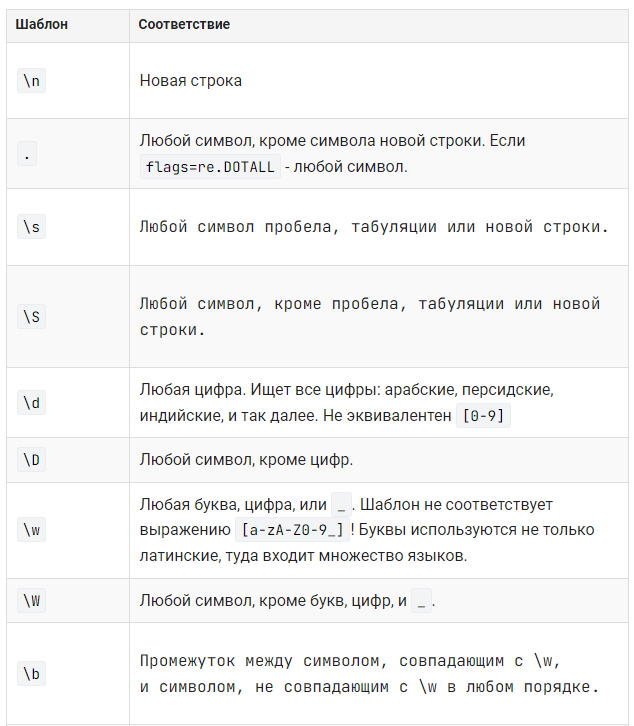

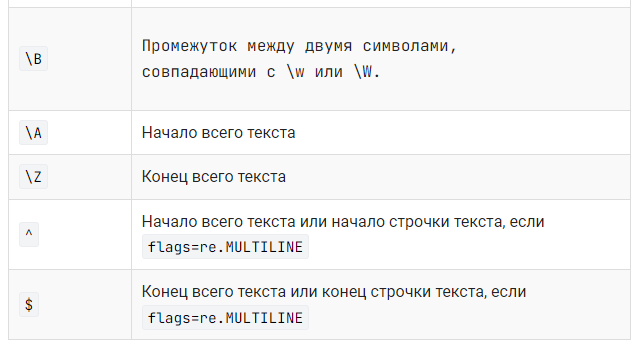

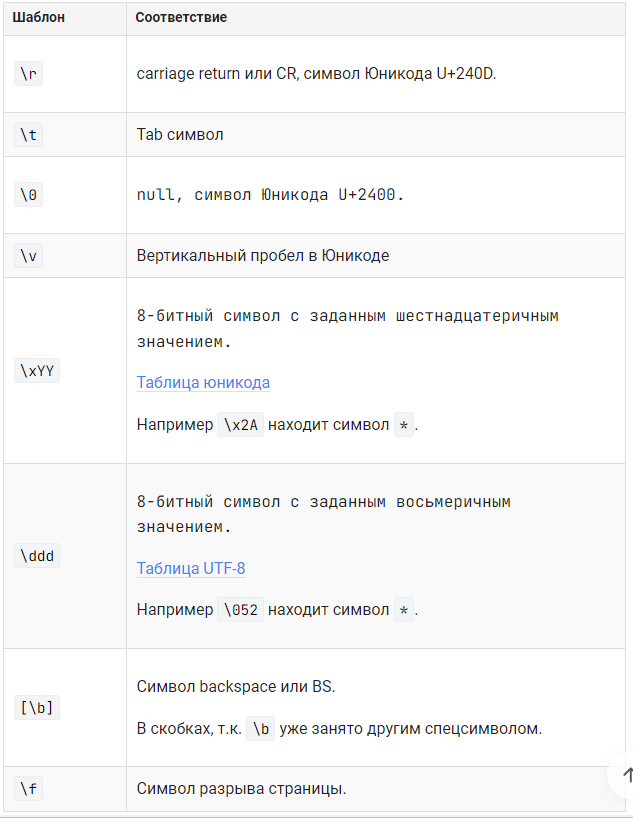

**``$``**

In [ ]:
r'[A$Z]'  # Ищет символы A,$,Z
r'^text$' # Ищет text между началом и концом строки
r'100\$'  # Ищет 100$

**``^``**

In [ ]:
r"[^abc]"      # Ищет любой символ, кроме a,b,c
r"^Some text$" # Ищет Some text между началом и концом строки
r"\^"          # Ищет символ ^ 
r"[a^bc]"      # Символ ^ не стоит первым в скобках, поэтому выражение ищет символы a,b,c,^

**``.``**

In [ ]:
r'[A.Z]'     # Ищет символы A,.,Z
r'text.'     # Ищет text с любым символом, кроме перехода на новую строку
r'1\.000\$'  # Ищет 1.000$

**``-``**

In [ ]:
r'Как-то так' # Ищет Как-то так
r'[+-]'       # Ищет символы +,-
r'[^-+]'      # Ищет любой символ, кроме +, -
r'[a-z]'      # Ищет все буквы латинского алфавита в нижнем регистре
r'[a\-z]'     # Ищет символы a,-,z

**``[]``**

In [ ]:
r'[abc]'   # Ищет символы a,b,c
r'\[abc\]' # Ищет [abc]
r'[\[abc\]]' # Ищет символы [,a,b,c,]

* ``^чебурек`` - **означает, что весь текст должен начинаться с шаблона "чебурек";**

* ``чебурек$`` - **означает, что весь текст должен закончится шаблоном "чебурек";**

* ``^чебурек$`` - **означает, что весь текст - это и есть "чебурек", потому что текст должен закончится им и начаться.**

**``\b`` и ``\B``**

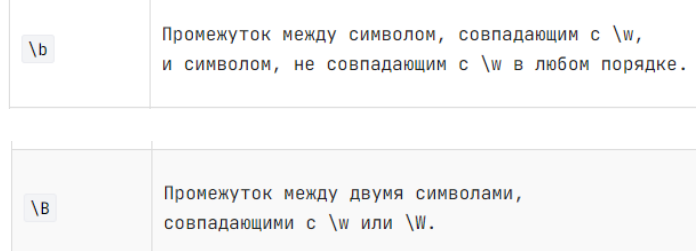

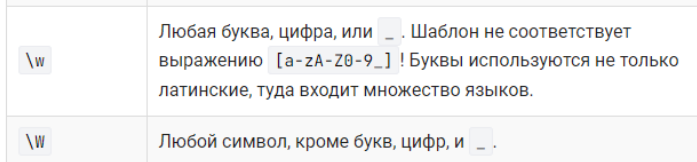

Т.е.
* ``\b`` - символ стоит после любого символа (цифры, буквы любого языка и _) и до некоторого знака, который к ним не относится
* ``\B`` - символ лежит между двумя знаками или двумя символами

Оно найдёт 123 в следующих примерах:
#123%
 123 
123
(123)
^123$
-123.

И пропустит 123 в этих примерах:
a123b
g123
123g
123_
_123
11234

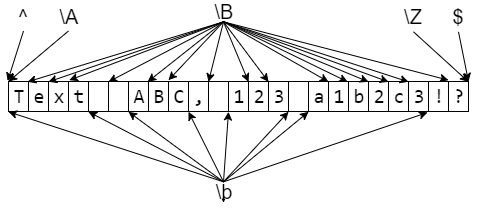

**``\b``**

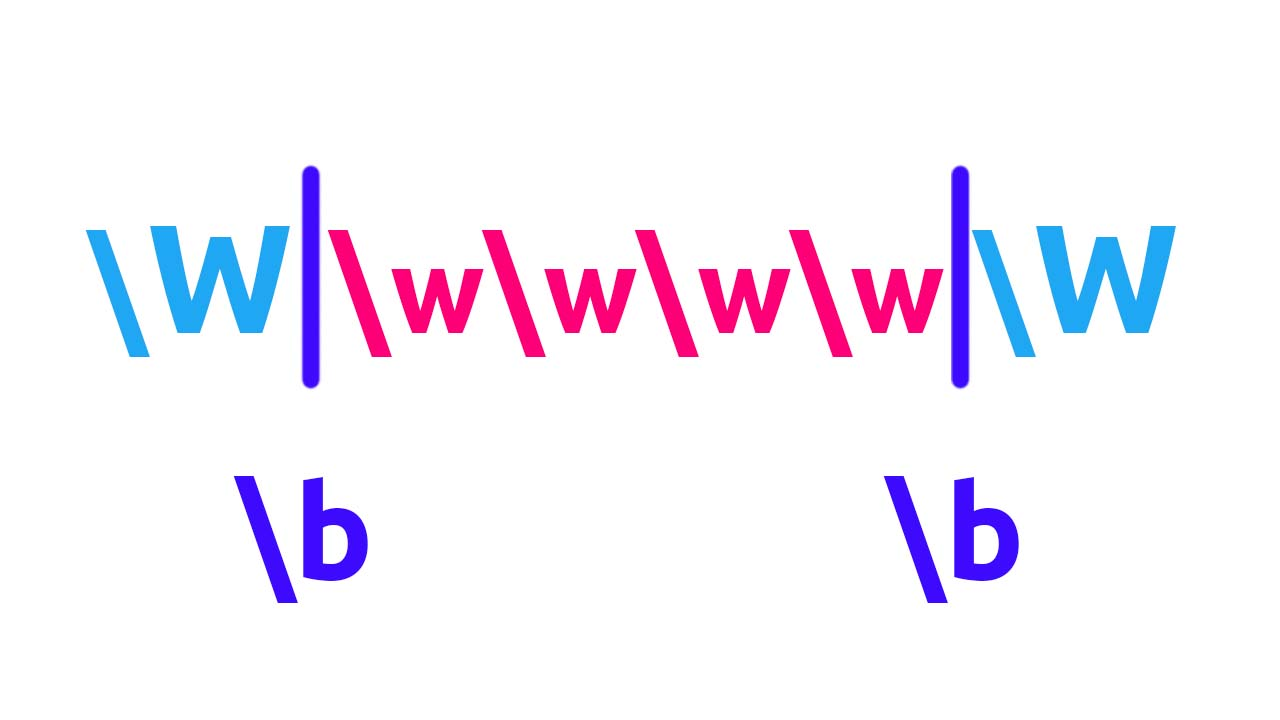

**``\B``**

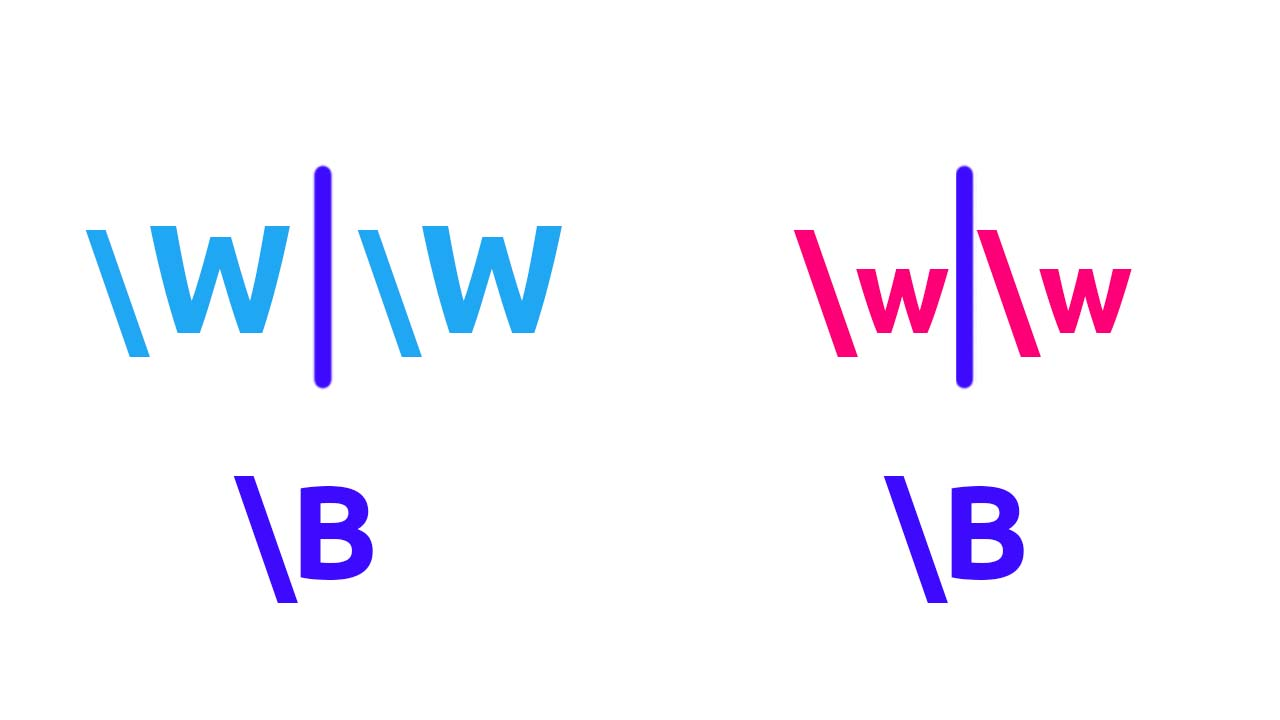

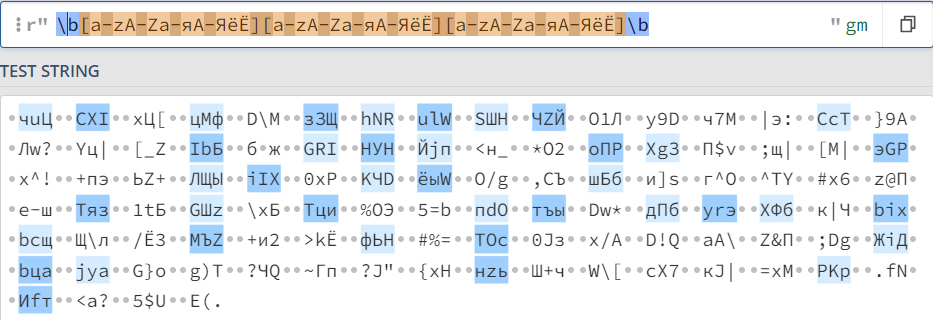

## Жадные квантификаторы

Очень часто, когда нужно использовать несколько шаблонов подряд, приходится их писать друг за другом. Например, если мы хотим найти 3 цифры подряд мы напишем:

In [93]:
r'\d\d\d'

'\\d\\d\\d'

In [94]:
r'\d{3}'

'\\d{3}'

**Квантификатор** - конструкция, которая позволяет указывать количество повторений.

* В каждом квантификаторе учитываются и начало, и конец отрезка.
* Каждый квантификатор по умолчанию - жадный. **Жадные квантификаторы** пытаются захватить как можно больше символов.

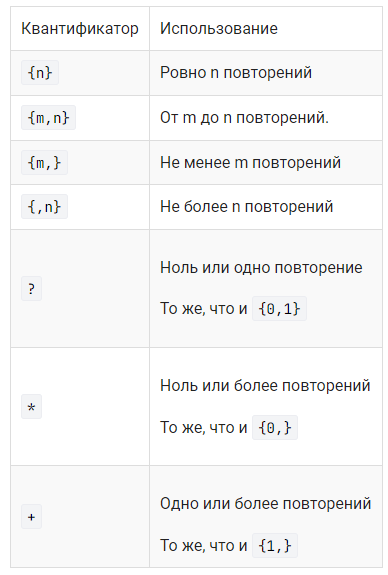

## Ленивые квантификаторы

Если после квантификатора поставить знак ?, то можно его сделать ленивым. Тогда он будет захватывать минимальное количество символов.

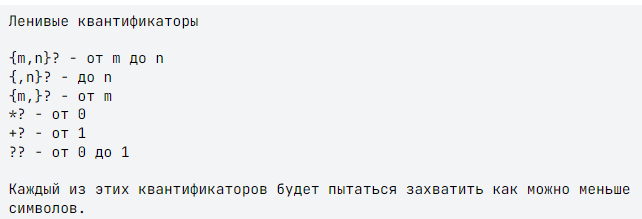

``{n}``=``{n}?``, так как в любом случае он будет искать нужную последовательность n раз, независимо от его жадности

## Группирующие скобки ``()``

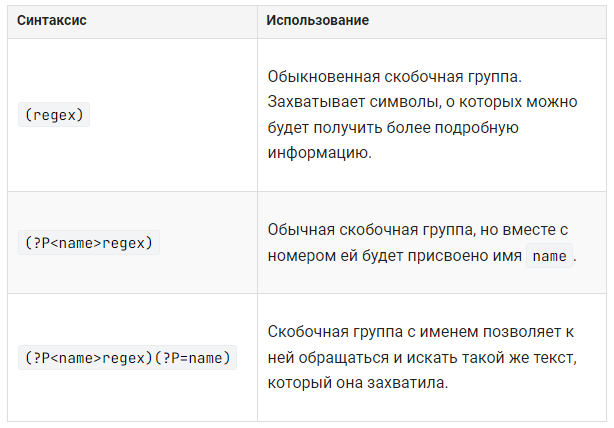

**(1)** Обычная группа ``([a-z]{4})``

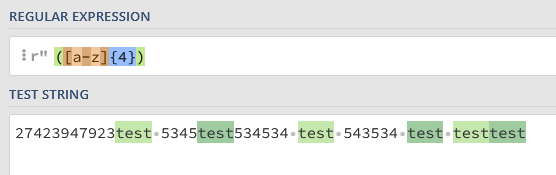

**(2)** Та же группа, только уже именованная ``(?P<name>[a-z]{4})``

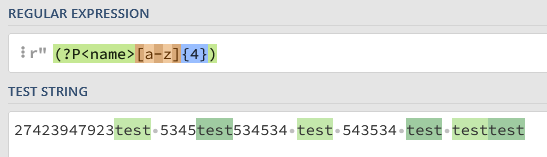

**(3)**  Снова именованная группа, но мы получаем текст, который она захватила ранее благодаря синтаксису ``(?P<name>[a-z]{4})(?P=name)``

НО можно обращаться как по имени, так и по порядку с 1

**"Не может быть подпоследовательностью" - надо выделять ``\b`` с двух сторон**

``\1``, ``\2`` - номера групп

## Условия ``(?(n)yes|no)``

В регулярных выражениях существуют условия. Если у группы ``n`` нашлись совпадения - возвращается шаблон до ``|``. В противном случае возвращается шаблон после ``|``. Шаблон после ``|`` необязателен и может быть опущен.

In [ ]:
regex = r"(a)?(?(1)b|c)"

# Группа (a)? ищет букву a. К группе применён квантификатор ?, 
# т.к. этой буквы может не быть в тексте
# Если в первой группе нашлась буква a, то
# условие (?(1)b|c) ищет букву b
# Если первая группа ничего не нашла, то условие ищет букву c

# В данном примере регулярное выражение найдёт все ab и c в тексте

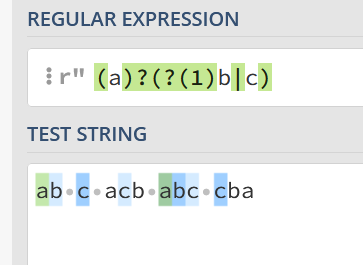

In [ ]:
regex = r"^(\[)?\d(?(1)\]|)$" # Выражение для поиска цифры в
# скобках или без скобок

# Группа (\[)? ищет первую скобку. К группе применён квантификатор ?,
# т.к. скобки может и не быть
# Условие (?(1)\]|) ищет правую скобку, если в первой группе 
# найдена левая скобка.
# Если первая группа ничего не нашла, то условие ничего не ищет.

# Найдёт 1 и [2]
# Проигнорирует 3] и [4

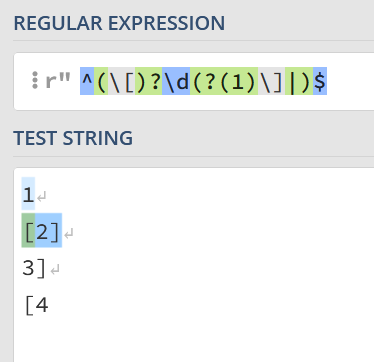

Если из регулярного выражения выше убрать дополнительные проверки, то оно будет находить не совсем то, что нужно:

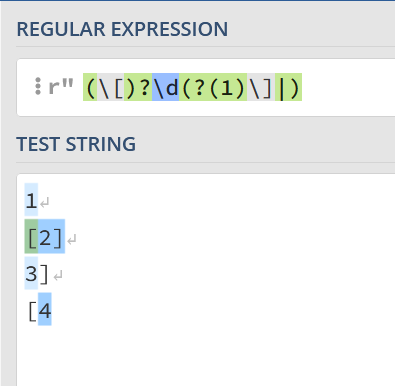

## Скобочные выражения

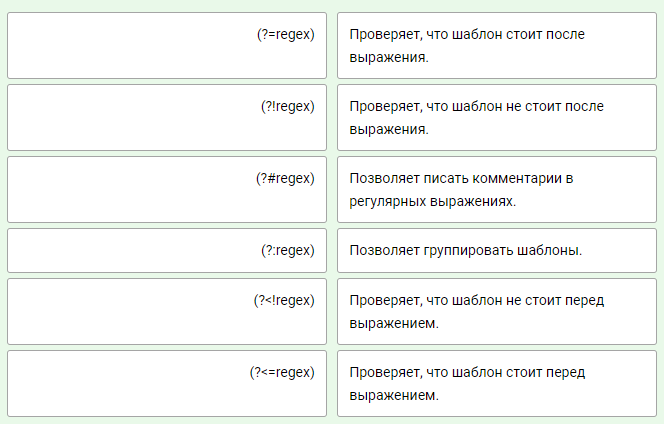

**Comment group**

``(?#)`` - скобочное выражение, позволяющее написать комментарий в регулярном выражении:

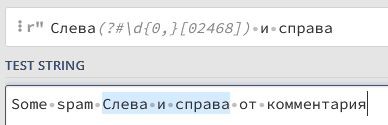

**Non-capturing group**

``(?:)`` - скобочное выражение, которое группирует регулярное выражение, но не захватывает в его группу. Так и называется - Non-capturing group, т.е. группа без захвата.

Его можно использовать, например, чтобы применять квантификаторы сразу к нескольким символам:

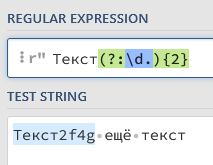

``(?:\d.){2}`` равносильно ``\d.\d.``

**Lookahead и Lookbehind**

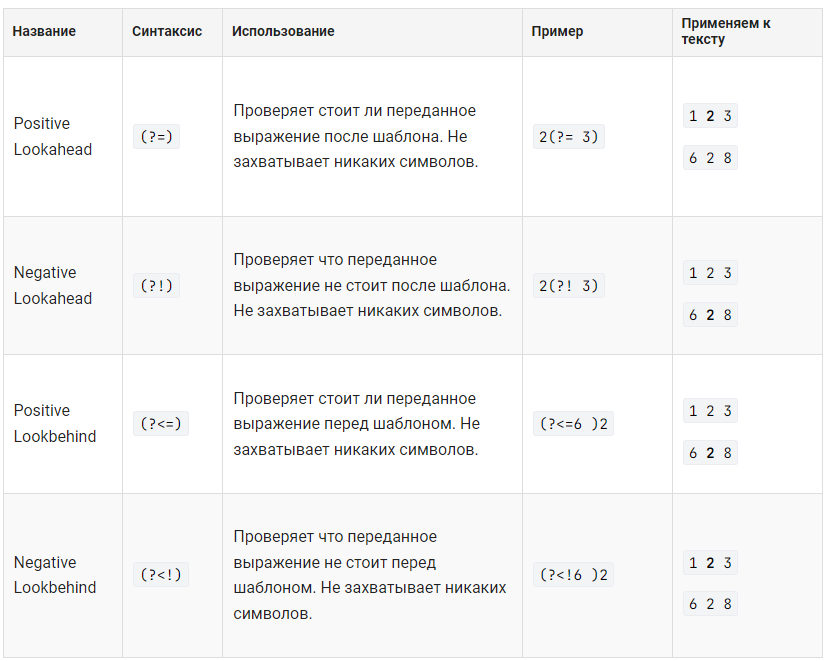

Давайте разберём их работу на наглядном примере. Допустим, нам нужно найти слово ``test``, окружённое среди двух цифр, но сами цифры захватывать не нужно. Тогда мы можем использовать скобочные выражения.

Напишем регулярное выражение, которое ищет слово test среди двух цифр, но не захватывает их: ``(?<=\d)test(?=\d)``.

Всё работает:

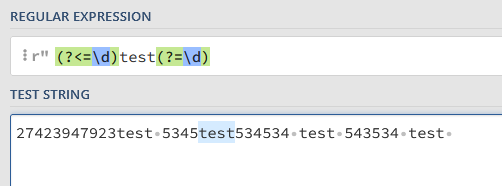

Обратите внимание, что все выражения в ``lookbehind`` должны быть фиксированной ширины, иначе вы получите ошибку ``re.error: look-behind requires fixed-width pattern``.

In [95]:
# Вызовут ошибку:

r'(?<=test{0,})regex'
r'(?<=g?)regex'
r'(?<!Python+)regex'

# Длина вхождений выражений в Lookbehind может быть разной
# Поэтому появится ошибка



# Ошибки не будет:

r'(?<=test)regex'
r'(?<=g{21})regex'
r'(?<!Pytho[mn])regex'

# Длина вхождений выражений в Lookbehind фиксированная
# Всё выполнится без ошибок

'(?<!Pytho[mn])regex'

## Операция ИЛИ

In [ ]:
r'Привет|Пока'

Обратите внимание, что в lookbehind можно использовать ``|``, только если все шаблоны одинаковой длины. То есть такие выражения будут правильными:

In [ ]:
r'(?<=hi!|bye)'
r'(?<![abcdef]|\d)'
r'(?<=\w|\W|\s)'

Такое использование lookbehind вызовет ошибку re.error: look-behind requires fixed-width pattern:

Для того, чтобы обойти такое исключение, нужно использовать | в non-capturing group:

In [ ]:
(?:(?<=hi!)|(?<=long_text))
(?:(?<![abcdef])|(?<!\d{4}))
(?:(?<=\w\s)|(?<=\W))

**Оператор "Или" в квадратных скобках**

Очень часто вижу эту ошибку у учеников, начинающих изучать регулярные выражения. Если вы поставите символ | в квадратные скобки, то ваш шаблон будет просто искать этот символ. Он не будет работать как оператор "Или". 

In [ ]:
# Задача: Нужно найти слово Hi или Bye

wrong_regex = r'[Hi|Bye]'
# Неправильное регулярное выражение, 
# т.к. оно равносильно следующему выражению [BHeiy|]
# Квадратные скобки используются только для 
# замены символов, условие или в них не работает

correct_regex = r'(Hi|Bye)'
# Поставленную выше задачу решает

correct_regex2 = r'(?:Hi|Bye)'
# Non-capturing group идеально подходит для группировки шаблонов

correct_regex3 = r'Hi|Bye'
# Шаблон без групппировки. Также работает, 
# поставленную выше задачу решает

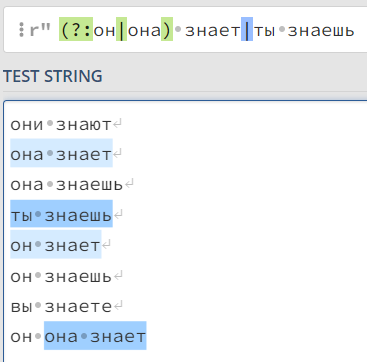

№ 345

Номер 741

Number 194

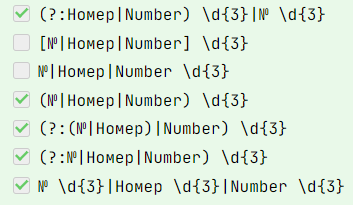

## Примеры

In [ ]:
regex = r'\w*[^A-Zа-яА-Я\s]+\w*\b'

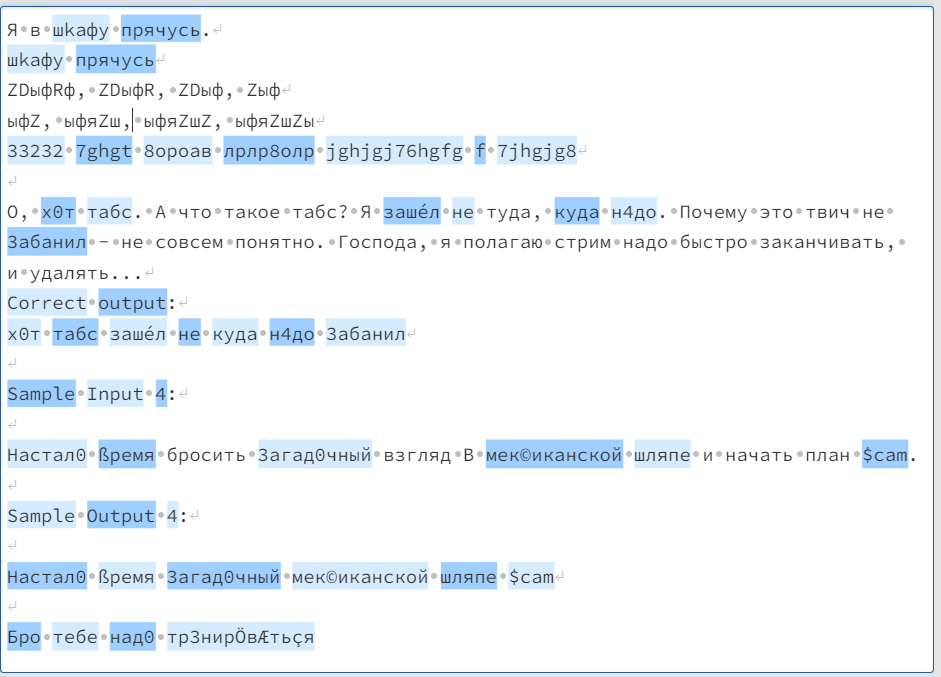

Вместо ``\b`` лучше использовать ``(?<!\S)`` и ``(?!\S)``

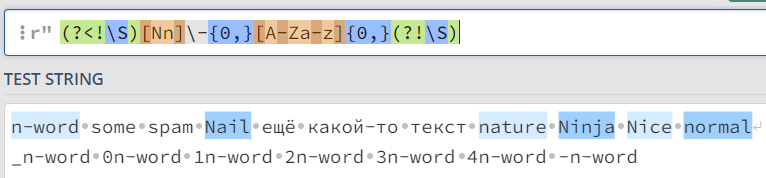

🐫 lowerCamelCase

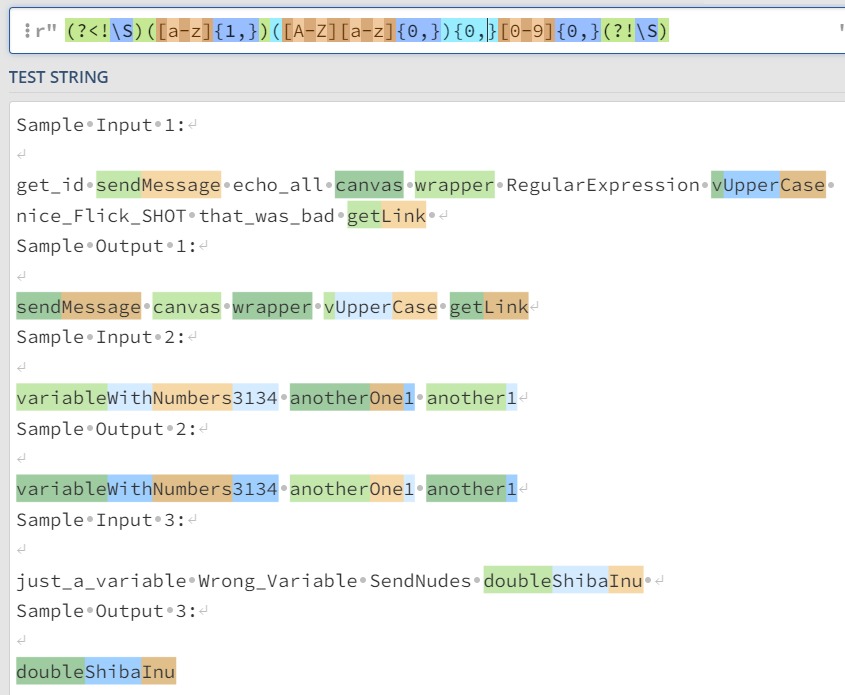

🐍 snake_case

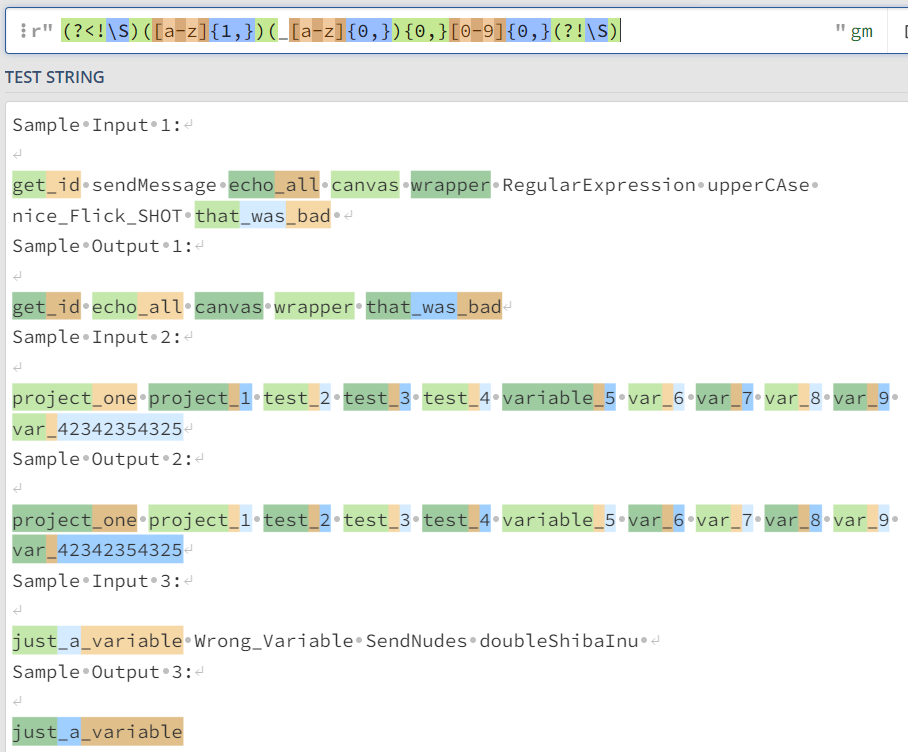

Имена телеграмм

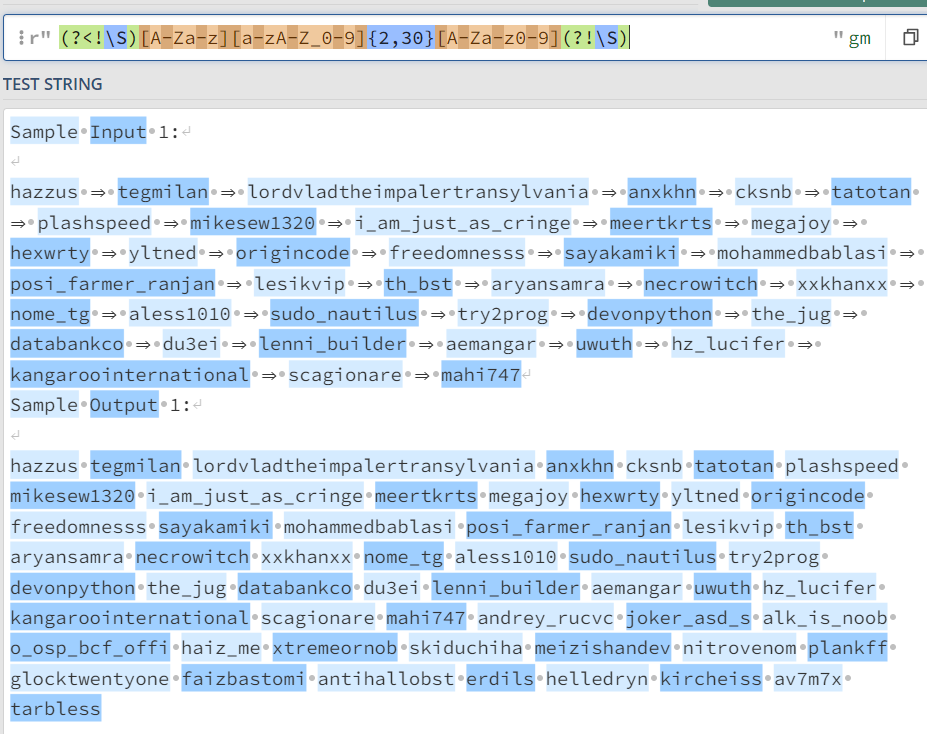

название.расширение

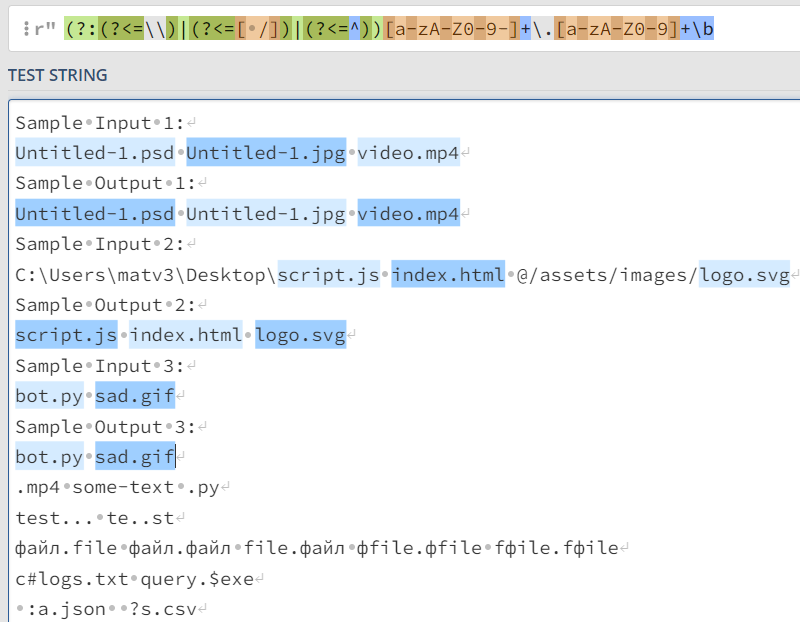

Верные массивы

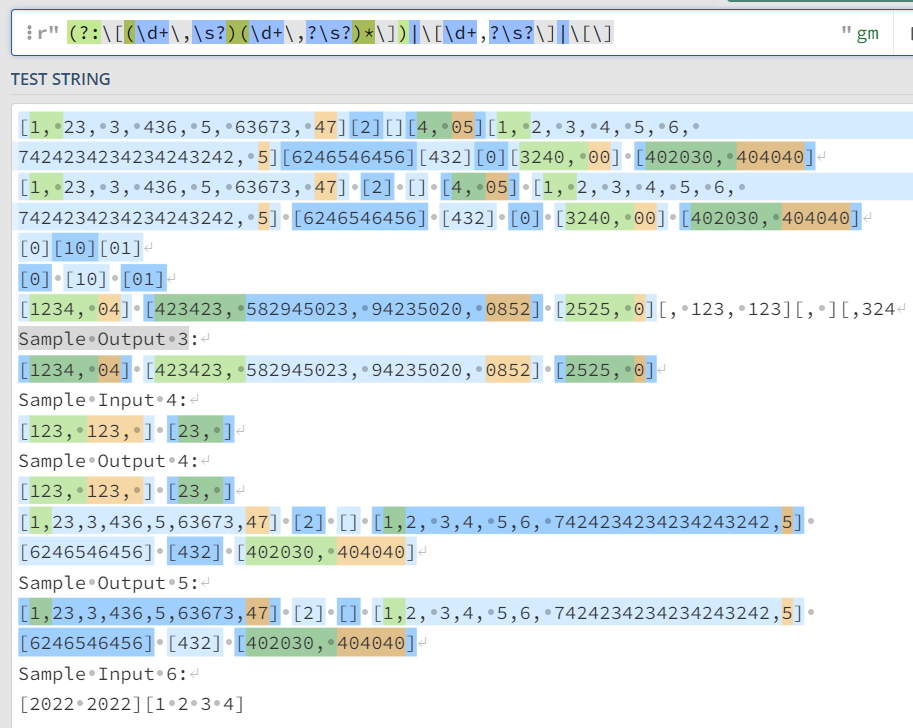

## catastrophic backtracking

Существует атака на сервисы, неправильно использующие регулярные выражения, позволяющая их замедлить или полностью вывести из строя. Такая атака называется ReDoS. Она основана на проблеме регулярных выражений под названием catastrophic backtracking. Если ваш сервис проверяет данные с помощью регулярных выражений с catastrophic backtracking и без дополнительных проверок, то выполнение регулярного выражения может занять очень большое время.

Допустим, у нас есть такое регулярное выражение: ``r"(a+)+b"``. Да, такое выражение можно представить как a+b, но давайте будем считать, что a и b - какие-то очень сложные регулярные выражения. Если строка, в которой мы ищем этот шаблон, не будет содержать b, то выражение перебирает строку огромным количеством способов, пытаясь найти совпадение. Время выполнения растёт экспоненциально:

In [96]:
import re

# Запустим выражение на строке из 20 символов a:
re.findall(r"(a+)+b", "a" * 20) 
# Выполнилось за 0.07218690006993711

# Запустим выражение на строке из 30 символов a:
re.findall(r"(a+)+b", "a" * 30) 
# Выполнилось за 75.4667053000303

# Прирост более чем в тысячу раз!!!

[]

Примеры таких выражений:
* ``(?:a+)+``
* ``([a-zA-Z_]+)*``
* ``(?:a|aa)+``
* ``(a|a?)+``

Есть следующие способы решить эту проблему:

1. Постараться переписать регулярное выражение, если это возможно (сократить количество квантификаторов и условий или)
2. Перед использованием выражения проверять входные данные (например, не принимать слишком большой текст)
3. Использовать специальные средства из модуля re (сейчас мы их пройдём)
4. Контролировать использование регулярного выражения (например, останавливать поиск, если он идёт слишком долго)

## Притяжательный квантификатор

Если после жадного квантификатора поставить +, то он станет притяжательным:
* ``{m,n}+``
* ``{,n}+``
* ``{m,}+``
* ``*+``
* ``++``
* ``?+``

Притяжательные квантификаторы, как и жадные, пытаются найти максимально возможное количество вхождений. Но, в отличие от жадных квантификаторов, они не разрешают back-tracking, когда регулярное выражение не может найти совпадение.

Это значит, что движок не будет проходить огромное количество путей и закончит свою работу раньше, если совпадение не будет найдено.

Как и в случае с ленивыми квантификаторами, смысла делать квантификатор ``{n}`` притяжательным нет.

## Атомарная группировка

Второе решение проблемы с catastrophic backtracking - атомарная группировка: ``(?>regex)``

Пытается найти вхождения regex, как если бы оно было отдельным регулярным выражением. Если совпадения найдены - движок регулярных выражений пытается найти совпадения для оставшейся части регулярного выражения, следующего после атомарной группировки. Если совпадений нет - движок регулярных выражения может откатиться назад только на место до атомарной группировки.

С помощью атомарной группировки можно сказать движку, что откатываться в этом месте и искать всевозможные пути не имеет смысла: внутри ``(?>regex)`` откат запрещён.

Например, выражение ``(?>.*)``. никогда не найдёт совпадений, потому что шаблон ``.*`` нашёл бы все возможные символы в тексте, и оставшаяся ``.`` не смогла бы найти совпадение.

* x{m,n}+ одно и то же, что и (?>x{m,n})
* x*+ одно и то же, что и (?>x*)
* x++ одно и то же, что и (?>x+)
* x?+ одно и то же, что и (?>x?)

In [1]:
import re
regex = r'(?:a)+b'
print(re.findall(regex, 'a'*50))

[]


## Объект Match

Он нужен чтобы получать более детальную информацию о найденных совпадениях. 

У объекта ``Match` есть несколько интересных методов и атрибутов:
* ``expand()``
* **``group()``**
* ``groups()``
* ``groupdict()``
* **``start()``**
* **``end()``**
* **``span()``**
* ``lastindex``
* ``lastgroup``
* **``pos``**
* **``endpos``**
* **``re``**
* **``string``**

**Нулевая группа**

Почти все методы принимают на вход необязательный аргумент __group. Этот аргумент - номер группы, у которой нужно получить соответствующее значение.

С группами мы будем работать позже, поэтому пока будем вызывать методы без аргументов или с аргументом 0.

Нулевая группа - полная строка, которую захватило регулярное выражение.

In [1]:
import re

regex = r'П.+?т'
text = 'Привет, как тебя зовут?'

# Не обращайте внимание на эту функцию, мы её разберём уже на следующем уроке
# Всё, что нужно о ней знать это то, что в результате своей работы она возвращает Match-объект
# В данном случае мы записываем Match-объект в переменную match

match = re.match(regex, text) 
match

<re.Match object; span=(0, 6), match='Привет'>

* ``span`` - индексы начала и конца совпадения
* ``match`` - само совпадение.

* ``group([group1, ...])`` - Возвращает найденное совпадение по номеру группы.
* ``start(__group=0)``, ``end(__group=0)`` - возвращают индексы начала и конца совпадения с регулярным выражением группы, номер которой был передан в метод:
* ``span(__group=0)`` - возвращает кортеж с индексом начала и конца совпадения группы, номер которой был передан в метод. Он работает аналогично методам start, end, но возвращает пару чисел:

In [4]:
print(match.group())  # Если в метод не передать аргумент, то он по умолчанию выведет нулевую группу
print(match.group(0)) # Можно передать номер нужной группы в метод
print(match[0])       # Благодаря геттеру в Match-объекте к группам можно обращаться с помощью квадратных скобок

# Все вызовы сверху выведут совпадение нулевой группы, т.е. всего регулярного выражения
# В данном случае они выведут строку "Привет"

Привет
Привет
Привет


In [5]:
print(match.start())  # 0
print(match.end())    # 6
print(match.start(0)) # 0
print(match.end(0))   # 6

0
6
0
6


In [6]:
print(match.span())  # (0, 6)
print(match.span(0)) # (0, 6)

(0, 6)
(0, 6)


**Атрибуты**
* ``pos`` -  это позиция, с которой функция начинает искать совпадения.
* ``endpos`` - это позиция, до которой функция ищет совпадения
* ``re`` -  получить регулярное выражение, которое использовалось для поиска
* ``string``- получить строку, в которой искались совпадения

In [7]:
print(match.pos) # 0
print(match.endpos) # 23
print(match.re) # re.compile('П.+?т')
print(match.string) # Привет, как тебя зовут?

0
23
re.compile('П.+?т')
Привет, как тебя зовут?


## Методы

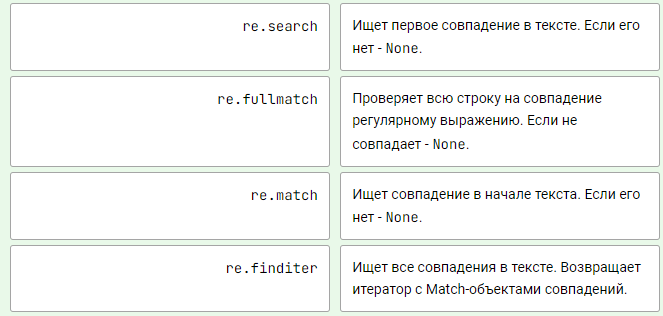

**``re.search(pattern, string, flags=0)``** - ищет первое совпадение в строке

*Параметры:*
* ``pattern`` - регулярное выражение
* ``string`` - строка, к которой нужно применить регулярное выражение
* ``flags`` - флаги, пройдём позже

*Output*
* Объект ``Match``, если совпадение было найдено
* ``None``, если нету совпадений

In [180]:
import re
pattern = r'\d{3}'
string = 'abc def fed cba'
# Ищет только одно вхождение, самое первое
result = re.search(pattern, string)

print(result) # <re.Match object; span=(4, 7), match='123'>

None


In [181]:
import re
result = re.search(r'\d{3}', "abcdef")
print(result) # None

None


In [10]:
import re
x='#traveler #traveller #traveltheworld #travelblog #traveladdict #mytravelgram #travels #travelphoto #traveldiaries #travellife #travelawesome #travelpics #natgeotravel #travelholic #travelbug #travelstoke #traveldeeper #travelgirl #luxurytravel #worldtraveler #travelers #solotravel #travelpic #travelmore #travellingthroughtheworld #traveldiary #ilovetravel'
pattern = r'#[a-z]+'
result = re.search(pattern, x)
print(result.group(0) if result else '')

#traveler


In [12]:
# Код писать сюда \(❤‿❤)/
import re
x=[input() for _ in range(3)]
s=0
for i in x:
    match=re.search(r'[Кк]од', input())
    if match!=None:
        print(match.span())
        s=1
        break
if s==0: 
    print('код не найден')

Хочу полететь на Марс(
Секретный код: Dogecoin
Батут работает!
Где ключи от моей Tesla?
ewerw
код не найден


In [14]:
# Код писать сюда \(❤‿❤)/
import re
x=[input() for _ in range(4)]
s=0
for i in range(len(x)):
    match=re.search(r'(?<=Activation key\: )[0-9A-Za-z]{5}\-[0-9A-Za-z]{5}\-[0-9A-Za-z]{5}\-[0-9A-Za-z]{5}\-[0-9A-Za-z]{5}(?<!S)', x[i])
    if match!=None:
        print(match.group())


Activation key: A70PM-KQ-BA-HYF2D-16CMK-OM4FP
JFP9D-7C4Z9-XHFMD-KH3TX-NTS6Z
Activatin key: ONHVS-A705Q-QIWMB-3TRKD-93JQV
gg key: J4DP3-WT02L-VK1DN-36ET7-MEKYI


**``re.match(pattern, string, flags=0)``** - то же самое, что и ``re.search()``, но ищет совпадение в начале строки.

*Параметры:*
* ``pattern`` - регулярное выражение
* ``string`` - строка, к которой нужно применить регулярное выражение
* ``flags`` - флаги, пройдём позже

*Output*
* Объект ``Match``, если совпадение было найдено
* ``None``, если нету совпадений

In [15]:
import re
pattern = r'\d{3}'
string = 'abc 123 def 456 fed 321 cba'
result = re.match(pattern, string)
print(result) # None

None


In [16]:
import re
pattern = r'\d{3}'
string = '123 abc 456 def 654 cba 321'
result = re.match(pattern, string)
print(result) # <re.Match object; span=(0, 3), match='123'>

<re.Match object; span=(0, 3), match='123'>


**``re.fullmatch(pattern, string, flags=0)``** - определяет соответствие строки переданному шаблону. Если вся строка соответствует шаблону - выводит объект Match, иначе - None.

*Параметры:*
* ``pattern`` - регулярное выражение
* ``string`` - строка, к которой нужно применить регулярное выражение
* ``flags`` - флаги, пройдём позже

*Output*
* Объект ``Match``, если совпадение было найдено
* ``None``, если нету совпадений

In [17]:
import re
print(re.fullmatch('\d', '111')) # None
print(re.fullmatch('\d', '1'))   # <re.Match object; span=(0, 1), match='1'>

None
<re.Match object; span=(0, 1), match='1'>


**Номер телефона**
* Номер может начинаться с +
* Потом идут цифры
* В каждом номере минимум 11 цифр
* Между цифрами могут быть разделители: ( )-
* Длина разделителя от 0 до 2 символов включительно

In [19]:
# Код писать сюда \(❤‿❤)/
import re

print(re.fullmatch(r'(?<!\S)\+{0,1}[0-9]{1,} {0,1}(\([0-9]{3}\)|[0-9]{3}) {0,1}[0-9]{3}([ \-]{0,1}[0-9]{2}){2}', input()) is not None)

+688 893 512 92 14
True


**``re.finditer(pattern, string, flags=0)``** -возвращает итератор Match объектов с вхождениями pattern в строке string.

*Параметры:*
* ``pattern`` - регулярное выражение
* ``string`` - строка, к которой нужно применить регулярное выражение
* ``flags`` - флаги, пройдём позже

*Output*
* Итератор ``Match`` объектов

In [170]:
import re

pattern = r'\d{3}'
string = 'abc 123 def 456 fed 321 cba'

result = re.finditer(pattern, string, 0)

for i in result:
    print(i.group())
    
# В данном примере будет выведено:
# <re.Match object; span=(4, 7), match='123'>
# <re.Match object; span=(12, 15), match='456'>
# <re.Match object; span=(20, 23), match='321'>

123
456
321


In [175]:
pattern = r'123'
string = 'abc 123 def 456 fed 321 cba'

result = re.search(pattern, string, 0)
result.pos

In [172]:
pattern = r'\d{3}'
string = 'abc 123 def 456 fed 321 cba'

result = re.search(pattern, string, 0)
print(result)

In [162]:
for i in result:
    print(i.group())

123
456
321


**``re.findall(pattern, string, flags=0)``** - возвращает список всех найденных совпадений

*Параметры:*
* ``pattern`` - регулярное выражение
* ``string`` - строка, к которой нужно применить регулярное выражение
* ``flags`` - флаги, пройдём позже

*Output*
* Список совпадений, если они есть
* Пустой список, если совпадений нет

In [182]:
import re

pattern = r'\d{3}'
string = 'abc 123 def 456 fed 321 cba'

result = re.findall(pattern, string)

print(result) # ['123', '456', '321']

['123', '456', '321']


In [217]:
re.findall(r'(?<=\b\w)\w','htis si a etxt')
# print(re.findall(r'\b\w','htis si a etxt'))


['t', 'i', 't']

In [284]:
import re
alllines=['this is a text',
'\"this\' !is. ?n1ce,','Two*****words','Oneword','Two words',
          'htis si a etxt','36set ld a "32den"','this.cool']
for line in alllines:
    line = line.rstrip()
    reg=re.findall(r'\w{2,}',line)
    for i in range(len(reg)):
        z=list(reg[i])
        z[0],z[1]=z[1],z[0]
        z=''.join(z)
        line=re.sub(f'(?<!\w){reg[i]}',z, line)
    print(line)
    

htis si a etxt
"htis' !si. ?1nce,
wTo*****owrds
nOeword
wTo owrds
this is a text
63set dl a "23den"
htis.ocol


In [275]:
alllines=['this is a text',
'\"this\' !is. ?n1ce,','Two*****words','Oneword','Two words',
          'htis si a etxt','36set ld a "32den"','this.cool']
x=re.findall(r'\w{2,}',alllines[1])
for i in x:
    ''.join(list(map(lambda x: x[0],x[1]=x[1],x[0])))
    re.sub(,i)

['this', 'is', 'n1ce']

**Цифровые часы**

In [24]:
# Код писать сюда \(❤‿❤)/
import re
string=input()
pattern = r'(?<!\S)(?:2[0-3]|[01][0-9]|)\:[0-5][0-9](?!\S)'

result = re.findall(pattern, string, 0)

for i in result:
    print(i)


05:51 22:57 23:02 07:64 14:73 09:09 09:51 47:61 48:17 52:74 77:29 12:25 06:39 36:26 02:06 09:37 69:11 58:50 20:70 25:44 18:66 41:52 39:41 48:77 65:62 23:32 60:07 73:13 71:79 67:64 15:28 46:74 22:03 42:10 18:56 49:24 78:66 07:48 04:47 49:78 18:42 45:16 01:64 26:39 06:01 72:58 76:75 75:13 44:58 53:50 46:25 00:47 00:18 78:69 36:60 28:08 13:00 42:73 37:54 29:66 14:26 21:66 16:46 49:03 52:33 34:40 75:73 57:35 36:22 24:63 38:77 58:77 76:17 65:73 46:03 47:42 26:35 76:41 32:73 62:76 77:12 56:44 48:27 37:25 73:77 79:79 76:29 44:05 66:47 20:11 38:00 02:22 33:50 53:16 29:17 47:62 21:16 33:02 76:37 11:43
05:51
22:57
23:02
09:09
09:51
12:25
06:39
02:06
09:37
23:32
15:28
22:03
18:56
07:48
04:47
18:42
06:01
00:47
00:18
13:00
14:26
16:46
20:11
02:22
21:16
11:43


**Все ссылки под ``a``-тегом**

In [52]:
# Код писать сюда \(❤‿❤)/
string=input()
import re

res1 = re.findall(r'(?<=\<a).{1,}(?=\</a\>)', string, 0)
res2 = re.findall(r'(?<=href\=\")([A-Za-z/\.\:]{1,})(?=\")', res1[0], 0)
for i in res2:
    print(i)

<html lang="en"><head><meta charset="UTF-8"><meta http-equiv="X-UA-Compatible" content="IE=edge"><meta name="viewport" content="width=device-width, initial-scale=1.0"><title>Пролистай вниз</title><link rel="stylesheet" href="./css/normalize.css"><link rel="stylesheet" href="./css/style.css"><link rel="icon" href="./img/icon.jpg"></head><body><header><h1 class="privet">Привет!<br>Пролистай страничку вниз.</h1><img src="./img/photo.jpg" alt="" class="logo_icon"></header><main><p class="paragraph">Чтобы продолжить - отправь боту любое фото.</p></main><footer><a class="link" href="./img/photo.jpg" download="">Фото</a><p class="link">id стикера - CAACAgIAAxkBAAIDxWITCaZnaUelQ0SNlHMTrjd2klAmAAIBAQACVp29CiK-nw64wuY0IwQ</p><a class="link" href="./img/tochno.txt" download="">Документ</a></footer></body></html>
./img/photo.jpg
./img/tochno.txt


**``re.split(pattern, string, maxsplit=0, flags=0)``** - разбивает строки по заданному паттерну.

*Параметры:*
* ``pattern`` - регулярное выражение
* ``string`` - строка, к которой нужно применить регулярное выражение
* ``maxsplit`` - максимальное количество делений строки
* ``flags`` - флаги, пройдём позже

*Output*
* Если совпадения есть - список частей разделённой строки.
* **[string]**, если совпадений нет

In [53]:
import re

pattern = r'\s\d{3}\s'
string = 'abc 123 def 456 fed 321 cba'

result = re.split(pattern, string)

print(result) # ['abc', 'def', 'fed', 'cba']

['abc', 'def', 'fed', 'cba']


In [54]:
import re

pattern = r'\s\d{3}\s'
string = 'abc 123 def 456 fed 321 cba'

result = re.split(pattern, string, 2)

print(result) # ['abc', 'def', 'fed 321 cba']

['abc', 'def', 'fed 321 cba']


In [55]:
import re

pattern = r'123'
string = '456'

result = re.split(pattern, string)

print(result) # ['456']

['456']


In [96]:
# Код писать сюда \(❤‿❤)/
import re
string = 'Категория: Телефоны\nSupreme Burner\nMotorola Razr\nКатегория: Смарт часы и браслеты\nApple Watch 6\nGarmin Venu\nXiaomi Mi Smart Band 6\nКатегория: Игры\nSpore'
result = re.split(r'Категория\: ', string)
result=''.join(result)
result=re.split(r'[А-Яа-яёЁ ]{1,}\n', result)
print(result)

['', 'Supreme Burner\nMotorola Razr\n', 'Apple Watch 6\nGarmin Venu\nXiaomi Mi Smart Band 6\n', 'Spore']


**``re.sub(pattern, replace, string, count=0, flags=0)``** - заменяет найденные вхождения на заданные символы и возвращает исправленную строку.

*Параметры:*
* ``pattern`` - регулярное выражение
* ``replace`` - то, на что нужно заменить найденное вхождение
* ``string`` - строка, к которой нужно применить регулярное выражение
* ``count`` - необязательный аргумент, максимальное число вхождений, подлежащих замене. Если этот параметр опущен или равен нулю, то произойдет замена всех вхождений.
* ``flags`` - флаги, пройдём позже

*Output*
* Если совпадения есть - изменённая строка
* ``string``, если совпадений нет

In [97]:
import re


pattern = r'[a-z]{3}'
replace = '111'
string = 'abc 123 def 456 fed 321 cba'

result = re.sub(pattern, replace, string)

print(result) # 111 123 111 456 111 321 111

111 123 111 456 111 321 111


In [98]:
import re


pattern = r'[a-z]{3}'
replace = '111'
string = 'abc 123 def 456 fed 321 cba'

result = re.sub(pattern, replace, string, 2)

print(result) # 111 123 111 456 fed 321 cba

111 123 111 456 fed 321 cba


In [118]:
z=list('asdasdas')
z[0],z[1]=z[1],z[0]
z

['s', 'a', 'd', 'a', 's', 'd', 'a', 's']

In [99]:
import re


pattern = r'[a-z]{10}'
replace = '111'
string = 'abc 123 def 456 fed 321 cba'

result = re.sub(pattern, replace, string)

print(result) # abc 123 def 456 fed 321 cba

abc 123 def 456 fed 321 cba


In [110]:
import re

f, i, o = map(lambda x: x[:-1], input().split())
w = r'[а-я]'
print(re.sub(fr'({f}{w}* {i}{w}* {o}{w}*)|({f}{w}* {i[0]}. {o[0]}.)', r'ФИО', input()))


На оборотной стороне приказа размещаются реквизиты "визы согласования документа" и "отметка об исполнителе". Главный инженер ФИО 23.03.2005


ValueError: too many values to unpack (expected 3)

In [109]:
a, b, c = input().split() - для начала разбиваем строку.
input_msg = input() - затем сам текст.
result = re.sub(fr'({a}[а-яё]*\s{b[0]}\.\s{c[0]}\.)','ФИО')
print(result) # 111 123 111 456 fed 321 cba

Калашников Дмитрий Митрофанович
Калашников Д. М. Калашникову Д. М. Калашникова Д. М. Калашниковым Д. М. Калашникове Д. М. | Калашников Дмитрий Митрофанович Калашникову Дмитрию Митрофановичу Калашникова Дмитрия Митрофановича Калашниковым Дмитрием Митрофановичем Калашникове Дмитрие Митрофановиче Калашников Денис Митрофанович Калашёв Дмитрий Митрофанович Калашёв Д. М. Калашников Дмитрий Митрофанов
Калашников Д. М. Калашникову Д. М. Калашникова Д. М. Калашниковым Д. М. Калашникове Д. М. | Калашников Дмитрий Митрофанович Калашникову Дмитрию Митрофановичу Калашникова Дмитрия Митрофановича Калашниковым Дмитрием Митрофановичем Калашникове Дмитрие Митрофановиче Калашников Денис Митрофанович Калашёв Дмитрий Митрофанович Калашёв Д. М. Калашников Дмитрий Митрофанов


**``re.subn(pattern, replace, string, count=0, flags=0)``** - выполняет ту же операцию, что и функция re.sub(), но возвращает кортеж.

*Параметры:*
* ``pattern`` - регулярное выражение
* ``replace`` - то, на что нужно заменить найденное вхождение
* ``string`` - строка, к которой нужно применить регулярное выражение
* ``count`` - необязательный аргумент, максимальное число вхождений, подлежащих замене. Если этот параметр опущен или равен нулю, то произойдет замена всех вхождений.
* ``flags`` - флаги, пройдём позже

*Output*

Кортеж (``new_string``, ``number_of_subs``), где

* ``new_string`` - новая строка, или старая, если не было совершено замен.
* ``number_of_subs`` - количество сделанных замен

In [111]:
import re


pattern = r'[a-z]{3}'
replace = '111'
string = 'abc 123 def 456 fed 321 cba'

result = re.subn(pattern, replace, string)

print(result) # ('111 123 111 456 111 321 111', 4)

('111 123 111 456 111 321 111', 4)


**``re.escape(pattern)``** - экранирует специальные символы в pattern. Полезно, если нужно использовать полученную строку как регулярное выражение, но в ней могут содержаться спецсимволы.

Если в метод передавать не сырую строку, а обычную - некоторые символы могут экранироваться и "потеряться". В итоге вы получите немного не ту строку для регулярного выражения, которую вы ожидали.

Это и логично, ведь если мы передаём строку в метод ``re.escape()`, то мы ожидаем, что она может содержать экранируемые последовательности или спецсимволы из регулярных выражений.

*Параметры:*
* ``pattern`` - строка, в которой нужно экранировать спецсимволы, чтобы впоследствии использовать в регулярном выражении.

*Output*
* Строка, с экранированными спецсимволами

In [112]:
import re

print(re.escape(r'https://stepik.org/lesson/694442/step/1?unit=694231'))
# Выводит https\:\/\/stepik\.org\/lesson\/694442\/step\/1\?unit\=694231

https://stepik\.org/lesson/694442/step/1\?unit=694231


## Группы

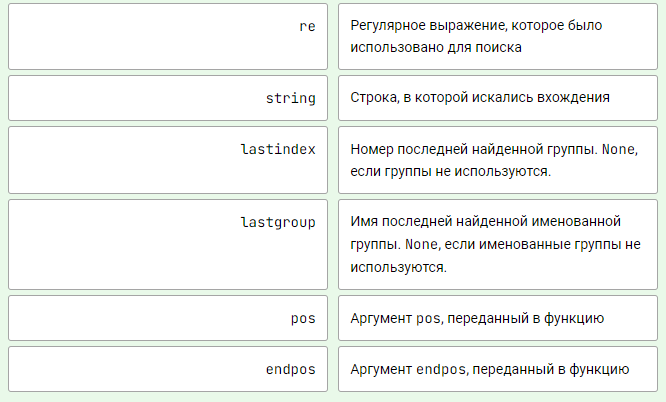

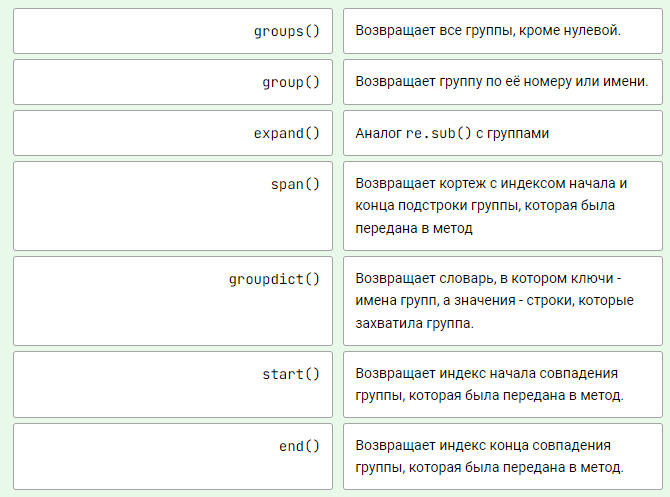

Теперь стоит пройти все методы и атрибуты более подробно:
* ``expand()``
* ``group()``
* ``groups()``
* ``groupdict()``
* ``start()``
* ``end()``
* ``span()``
* ``lastindex``
* ``lastgroup``
* ``pos``
* ``endpos``
* ``re``
* ``string``

In [2]:
import re

regex = r'П(?P<name>.+?)т' # Захватим весь текст между П и т в группу с именем name
text = 'Привет, как тебя зовут?'

match = re.match(regex, text) 
match

<re.Match object; span=(0, 6), match='Привет'>

**``group([group1, ...])``** - Возвращает найденное совпадение по номеру или имени группы.

**(1)** Попробуем получить нулевую группу, т.е. всё, что захватило регулярное выражение:

In [3]:
# Выведет строку "Привет":

print(match.group())  # Если в метод не передать аргумент, то он по умолчанию выведет нулевую группу
print(match.group(0)) # Можно передать номер нужной группы в метод
print(match[0])       # Благодаря геттеру в Match-объекте к группам можно обращаться с помощью квадратных скобок

Привет
Привет
Привет


**(2)** Теперь переходим в первой группе

In [4]:
# Выведет строку "риве":

print(match.group(1)) # Получаем то, что захватила первая группа
print(match[1])       # Получаем то, что захватила первая группа через квадратные скобки

риве
риве


**(3)**  Если обратиться к несуществующей группе, то получим ошибку ``IndexError: no such group:``

In [5]:
# Ошибка: IndexError: no such group

print(match.group(2))
print(match[2])

IndexError: no such group

**(4)** Если у группы есть имя, то по нему можно получить нужную группу:

In [6]:
# Выведет строку "риве":

print(match.group("name")) # Получаем то, что захватила группа с именем name
print(match["name"])       # Получаем то, что захватила группа с именем name через квадратные скобки

риве
риве


**(5)** Через метод можно получить сразу несколько групп. Для этого нужно указать нужные группы через запятую:

In [7]:
# Выведет кортеж ('Привет', 'риве', 'риве'):

print(match.group(0, "name", 1))

('Привет', 'риве', 'риве')


**``start(__group=0)``**, **``end(__group=0)``** - Методы start и end возвращают индексы начала и конца совпадения с регулярным выражением группы, номер или имя которой были переданы в метод

In [8]:
print(match.start(0)) # 0
print(match.end(0))   # 6
print(match.start(1)) # 1
print(match.end(1))   # 5

0
6
1
5


In [9]:
print(match.span(0)) # (0, 6)
print(match.span(1)) # (1, 5)

(0, 6)
(1, 5)


**``groups(default=None)``** - Метод groups возвращает кортеж со всеми группами, кроме нулевой:

In [10]:
print(match.groups()) # ('риве',)

('риве',)


Если какая-либо группа ничего не нашла, то вместо найденного совпадения будет значение аргумента ``default``, по умолчанию это ``None``:

In [11]:
import re


regex = r'П(?P<name>.+?)т,(2 группа)?'
text = 'Привет, как тебя зовут?'
match = re.match(regex, text) 

print(match.groups())                    # ('риве', None)
print(match.groups("Ничего не найдено")) # ('риве', 'Ничего не найдено')

('риве', None)
('риве', 'Ничего не найдено')


**``groupdict(default=None)``** -  возвращает словарь, ключи которого - имена групп, а значения - найденные совпадения этих групп:

In [12]:
print(match.groupdict()) # {'name': 'риве'}

{'name': 'риве'}


**``expand(template)``** - Метод работает почти точь-в-точь как функция re.sub() с группами. Поэтому он будет пройден вместе с re.sub().

**``string``** - Если обратиться к атрибуту, то можно получить строку, в которой искались совпадения:

In [13]:
print(match.string) # Привет, как тебя зовут?

Привет, как тебя зовут?


**``lastindex``** - Возвращает номер последней найденной группы. None, если группы не используются.

In [15]:
print(match.lastindex) # 1

1


**``lastgroup``** - Возвращает имя последней найденной именованной группы. None, если именованные группы не используются.

In [ ]:
print(match.lastgroup) # name

In [16]:
import re


regex = r'П(?P<name>.+?)в(?P<name2>2 группа)?(?P<name3>ет)?,'
text = 'Привет, как тебя зовут?'
match = re.match(regex, text) 

In [17]:
match.groups(0)

('ри', 0, 'ет')

In [18]:
match.groupdict(0)

{'name': 'ри', 'name2': 0, 'name3': 'ет'}

In [19]:
match.lastindex

3

In [20]:
match[0]

'Привет,'

In [21]:
match.lastgroup

'name3'

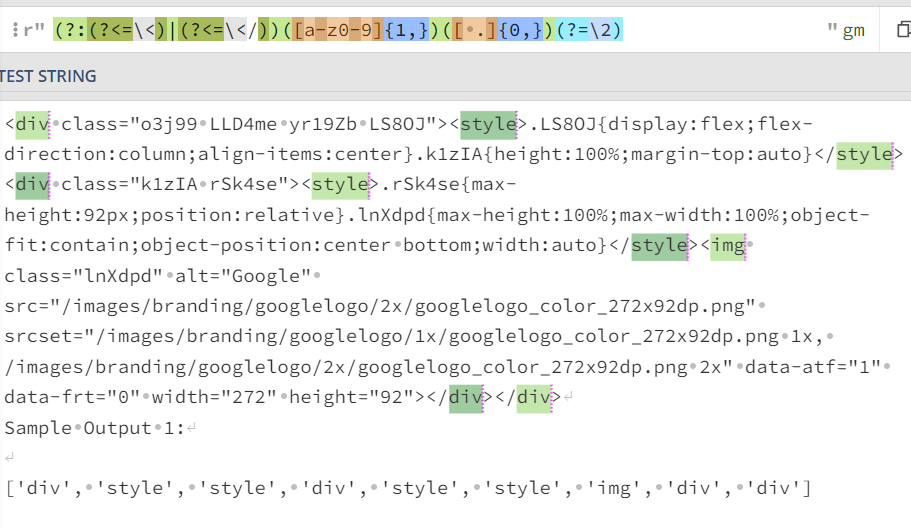

**Разделяем найденные ссылки**

In [ ]:
# Код писать сюда \(❤‿❤)/
# Код писать сюда \(❤‿❤)/
# Код писать сюда \(❤‿❤)/
import re
pattern = r"(?<!\S)(http[s]?)\://((?:www\.){0,1}[a-z]{1,}(?:\.[a-z]{1,}){0,})((?:/[a-z0-9\-_]{0,}){0,})(\?[a-z\=&0-9]{0,}){0,}(\#[a-z]{0,}){0,}(?!\S)"
string =input()

result = re.finditer(pattern, string,flags=0)

for i in result:
    print(f"""Полная ссылка: {i.group(0)}
Протокол: {i.group(1)} | Домен: {i.group(2)} | Параметры: {i.group(4)} | Якорь: {i.group(5)}
""")


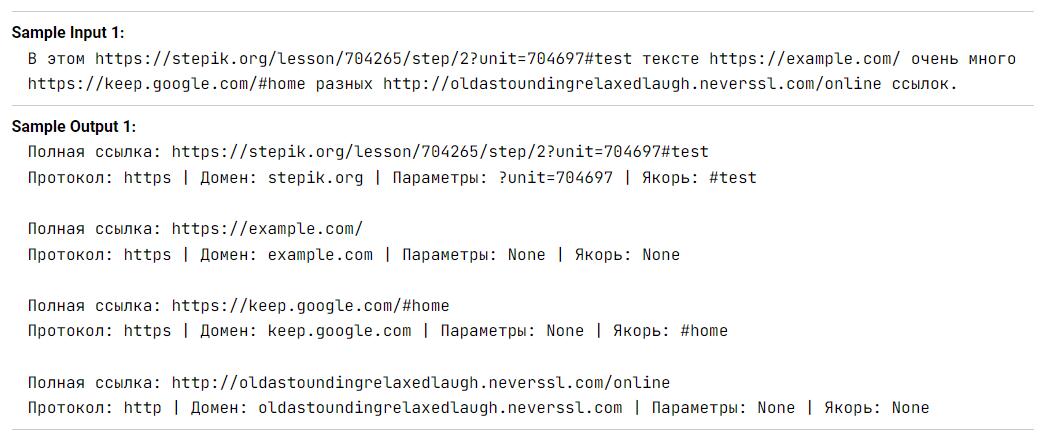

**Группы и ``re.split()``**

Если в шаблоне регулярного выражения используются групппы, то их значения будут вставлены между разделёнными строками:

In [ ]:
import re

res1 = re.split(r'\s[+*=]\s', '2 + 2 * 2 = 6')
# ['2', '2', '2', '6']
# Если в шаблоне нет групп, re.split работает так же, как и str.split

res2 = re.split(r'(\s)([+*=])(\s)', '2 + 2 * 2 = 6')
# ['2', ' ', '+', ' ', '2', ' ', '*', ' ', '2', ' ', '=', ' ', '6']
# Если использовать группы, то между каждыми разделёнными строками будут значения из групп

res3 = re.split(r'\s([+*=])\s', '2 + 2 * 2 = 6')
# ['2', '+', '2', '*', '2', '=', '6']
# Сначала не очень понятно, зачем использовать группы с re.split. 
# Но если убрать ненужные группы из второго примера, то всё становится ясно

Если выделить в группу, то символы-разделители будут в конечном результате. 

**Группы в ``re.sub()`` и ``re.subn()``**

Группы в ``re.sub()`` и ``re.subn()`` ничего не дают, но их можно использовать в заменах!

Если в строке, на которую будет происходить замена найденных совпадений написать \n или \g<name>, где n это номер группы, а name это имя группы, то они будут заменены на совпадения этих групп:


In [ ]:
import re

string = "Ненавижу людей, которые пишут дату в формате mm/dd/yyyy. Ну кто пишет 02/22/2022 или 07/13/2022?"
print(re.sub(r'(\d{2}).(\d{2}).(\d{4})', r'\2.\1.\3', string))
# Ненавижу людей, которые пишут дату в формате mm/dd/yyyy. Ну кто пишет 22.02.2022 или 13.07.2022?

In [ ]:
# Код писать сюда \(❤‿❤)/
# Код писать сюда \(❤‿❤)/
import re

pattern1=r'\*{2}(.{1,})\*{2}'
pattern2=r'\*{1}(.{1,})\*{1}'
string = input()
print(re.sub(pattern2, r'<em>\1</em>',re.sub(pattern1, r'<strong>\1</strong>', string)))


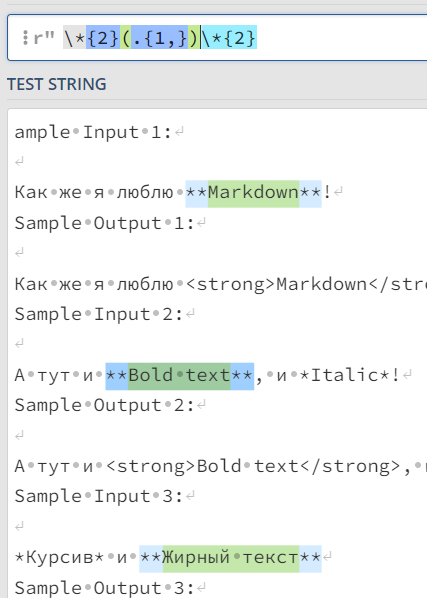

**Замените егонный/еённый/ихний на его/её/их**

In [ ]:
import re

patterns=[r'([Ее])гонный',r'([Ее])ённый',r'([иИ])хни[йе]']
repls=[r'\1го',r'\1ё',r'\1х']
string = input()


for i in range(len(repls)):
    string=re.sub(patterns[i] ,repls[i], string)
print(string)

**``match.expand()``**

Метод работает почти как функция re.sub() с группами:

In [1]:
import re


match = re.search(r"(\d{4})", "Бойцовский клуб (1999)")

print(match.expand(r"Год выпуска фильма: \1"))    # Год выпуска фильма: 1999

Год выпуска фильма: 1999


Зачем нужен ``match.expand()``?
``match.expand()`` генерирует строку, путём вставки в неё значений из найденных групп.

``re.sub()`` ищет совпадения в тексте, если совпадения найдены, то генерирует строку, путём вставки в неё значений из найденных групп, и заменяет совпадения на сгенерированные строки.

С помощью match.expand() удобно генерировать строки с найденными данными.

**Функции в ``re.sub()`` и ``re.subn()``**

Вместо строки, на которую нужно заменить вхождение, в ``re.sub()`` и ``re.subn()`` можно передать функцию, которая будет генерировать ту самую строку.

В функцию передаётся ``Match`` объект, и теперь мы можем получать доступ к группам, а также как-либо изменять и обрабатывать эти данные.

Например, нам нужно найти все слова и заменить их на их же длину. Давайте сделаем это с помощью функций!

In [ ]:
import re


def func(m):
    return str(len(m[0]))

regex = r'[a-zA-Z]{1,}'
text = 'Lorem Ipsum is simply dummy text of the printing and typesetting industry.'

res_func = re.sub(regex, func, text)
res_lambda = re.sub(regex, lambda m: str(len(m[0])), text)

print(res_func)  # 5 5 2 6 5 4 2 3 8 3 11 8.
print(res_func == res_lambda)  # True

В примере сверху в функциях я:

* Получаю ``Match`` объект в функции.
* Из него беру нулевую группу - т.е. всё, что захватило регулярное выражение.
* Получаю её длину, конвертирую в строку, и возвращаю значение.
* Можно использовать как и лямбда-функции, так и обычные.

**Замена чисел квадратами**

In [2]:
# Код писать сюда \(❤‿❤)/
import re
pattern=r'([0-9]{1,})'

string = 'Интересно, какое число получится, если 2022 возвести в квадрат?'

result = re.sub(pattern, lambda m: str(int(m[0])**2), string)
print(string)
print(result)

Интересно, какое число получится, если 2022 возвести в квадрат?
Интересно, какое число получится, если 4088484 возвести в квадрат?


In [40]:
'Abcvf1'.isalpha()

False

**Данные удалены**

In [4]:
# Код писать сюда \(❤‿❤)/
import re
pattern=r'\b[Аа][а-я]{0,}'

string = 'Абажур Аббревиатура Абзац абитуриент абонемент абонент'

result = re.sub(pattern, lambda m: f'удалено({len(m[0])})', string)
print(string)
print(result)

Абажур Аббревиатура Абзац абитуриент абонемент абонент
удалено(6) удалено(12) удалено(5) удалено(10) удалено(9) удалено(7)


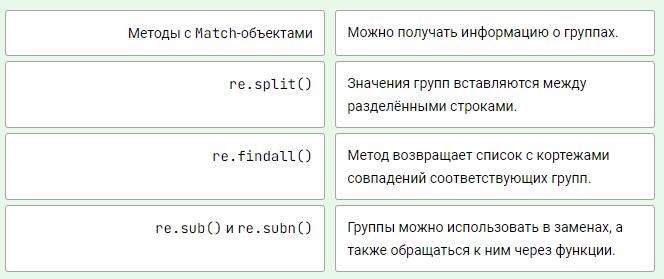

## Компиляции регулярных выражений

``re.compile(pattern, flags=0)`` - метод, который позволяет вручную компилировать регулярные выражения.

**Параметры:**

* ``pattern`` - регулярное выражение
* ``flags`` - флаги, пройдём позже

*Возвращаемое значение:*

Объект ``Pattern`` - скомпилированное регулярное выражение

Каждый раз, когда вы используете регулярное выражение в каком-либо методе, оно автоматически компилируется. С помощью метода ``re.compile()`` можно вручную скомпилировать регулярное выражение, и уже использовать его по назначению.

С помощью re.compile() можно:

* уменьшить количество кода, если одно регулярное выражение используется несколько раз
* увеличить производительность кода, если одно регулярное выражение используется несколько раз

In [ ]:
import re

regex = re.compile(r'[a-zA-Z]{1,}')
# Регулярное выражение скомпилировано

print(regex)  # re.compile('[a-zA-Z]{1,}')

# Теперь можно использовать методы:

print(regex.findall('Some words.'))  # ['Some', 'words']
print(regex.sub('deleted', 'Some words again.'))  # deleted deleted deleted.

**Объект ``Pattern``**

После компиляции регулярного выражения, функция ``re.compile()`` возвращает объект ``Pattern``.

Именно через этот объект можно обратиться ко всем функция из модуля ``re``, но они будут уже не функциями, а методами этого объекта.

In [5]:
import re

pattern = re.compile(r'(?P<group1>[a-zA-Z]{1,})')

**Атрибуты**

**``pattern.flags``**

Каждый флаг - хранится как какое-либо число. ``pattern.flags`` возвращает сумму этих чисел:

In [6]:
print(pattern.flags) # 32

32


**``pattern.groups``**

Возвращает количество групп в регулярном выражении:

In [7]:
print(pattern.groups) # 1

1


**``pattern.groupindex``**

Возвращает словарь, в котором ключи - именованные группы, а значения - номера этих групп:

In [8]:
print(pattern.groupindex) # {'group1': 1}

{'group1': 1}


**``pattern.pattern``**

Возвращает регулярное выражение:

In [9]:
print(pattern.pattern) # (?P<group1>[a-zA-Z]{1,})

(?P<group1>[a-zA-Z]{1,})


**Методы**

Благодаря объекту ``Pattern`` в методах ``search()``, ``match()``, ``fullmatch()``, ``finditer()``, ``findall()`` появляются дополнительные параметры:

* pos - позволяет указывать индекс в строке, с которого надо начать искать совпадение

* endpos - указывает, до какого индекса надо выполнять поиск

In [21]:
import re

pattern = re.compile(r'(?P<group1>[a-zA-Z]{1,})')

match1 = pattern.match("Some words.", 4) # None
match2 = pattern.match("Some words.", 5) # words
match2.group(0)

'words'

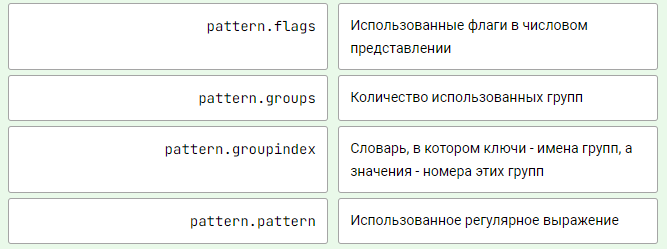

In [22]:
# Код писать сюда \(❤‿❤)/
string='soda senior tuition library task tone few torch vacuum'
spoint=2
epoint=29

import re

pattern = re.compile(r'(?<!\S)([a-zA-Z]{0,})(?!\S)')



match1 = pattern.search(string, spoint, epoint) # None
match1

<re.Match object; span=(5, 11), match='senior'>

In [13]:
pattern.match(string)

<re.Match object; span=(0, 4), match='soda'>

## Флаги

Чтобы использовать флаги, достаточно их передать как именованный аргумент в нужный метод:

In [ ]:
import re

test1 = re.findall('123', '123', flags=re.MULTILINE)  # 1 флаг
test2 = re.findall('123', '123', flags=re.MULTILINE + re.IGNORECASE)  # 2 флага
test3 = re.findall('123', '123', flags=re.MULTILINE + re.IGNORECASE + re.DOTALL)  # 3 флага

Если нужно использовать несколько флагов сразу - нужно сложить их вместе. Да, именно сложить.

Ну или написать между ними символ ``|``:

In [23]:
import re

test1 = re.findall('123', '123', flags=re.MULTILINE)  # 1 флаг
test2 = re.findall('123', '123', flags=re.MULTILINE | re.IGNORECASE)  # 2 флага
test3 = re.findall('123', '123', flags=re.MULTILINE | re.IGNORECASE | re.DOTALL)  # 3 флага

У флагов сущестуют сокращённые версии. Они позволяют сократить код в размере.

In [24]:
import re

test1 = re.findall('123', '123', flags=re.MULTILINE)  # 1 флаг
test2 = re.findall('123', '123', flags=re.MULTILINE + re.IGNORECASE)  # 2 флага
test3 = re.findall('123', '123', flags=re.MULTILINE + re.IGNORECASE + re.DOTALL)  # 3 флага

Если заменить флаги из примера с прошлого шага их сокращёнными версиями, то получим:

In [25]:
import re

test1 = re.findall('123', '123', flags=re.M)  # 1 флаг
test2 = re.findall('123', '123', flags=re.M + re.I)  # 2 флага
test3 = re.findall('123', '123', flags=re.M + re.I + re.S)  # 3 флага

**Встроенные флаги**

Также флаги можно указать в самом регулярном выражении. Достаточно просто поставить встроенный флаг перед регулярным выражением ``r"(?i)I like flags"``:

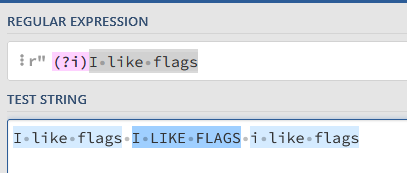

Встроенные флаги нужно ставить в начало выражения.

Если нужно использовать сразу несколько флагов - достаточно их перечислить: ``r"(?ims)I like flags"``.

**Локальные и глобальные флаги**

Все флаги которые только что были пройдены - глобальные, т.е. они действуют на всё регулярное выражение целиком.

Но что если нам нужно отключить флаг в какой-либо части выражения, или вообще использовать его только там?

На помощь приходят локальные флаги! Пока они есть только в встроенном виде: ``(?aiLmsux-imsx:regex)``

Все флаги до ``-`` используются вместе с ``regex``, а флаги, стоящие после ``-`` перестают работать с ``regex``.

Например, в следующем регулярном выражении:

In [26]:
regex = r"(?i)(?ms-i:local) global"

Используется глобальный флаг ``i``, но он будет работать только при поиске текста ``global``

А при поиске текста ``local``, флаг ``i`` отключается, и вместо него используются флаги ``m`` и ``s``.

**Объект RegexFlag**

Ещё совсем недавно мы получали из объекта ``Pattern`` флаги в числовом виде. Чтобы конвертировать их в привычный нам вид, достаточно провести следующие манипуляции:

In [27]:
import re

pattern = re.compile(r'[a-zA-Z]{1,}')
print(pattern.flags) # 32
print(re.RegexFlag(32)) # re.UNICODE

32
re.UNICODE


**``re.IGNORECASE``** (``re.I``); (``(?i)``); (``2``)

При использовании флага регулярные выражения будут игнорировать регистр.

In [28]:
import re

string = 'I like flags I LIKE FLAGS i like flags'

test1 = re.findall(r'I like flags', string, flags=re.IGNORECASE)
test2 = re.findall(r'I like flags', string, flags=re.I)
test3 = re.findall(r'(?i)I like flags', string)

print(test1)  # ['I like flags', 'I LIKE FLAGS', 'i like flags']
print(test1 == test2 and test2 == test3)  # True

['I like flags', 'I LIKE FLAGS', 'i like flags']
True


True

In [29]:
# Код писать сюда \(❤‿❤)/
import re

string='ПРИВЕТспампрИвЕТspamпРИвет123ПРИвЕт456ПРиВет789ПРиВет10пРиВЕТПокаПРиВеТHiпРИВетHelloПРиветTest'

print(re.findall(r'(?i)ПРИВЕТ', string))


['ПРИВЕТ', 'прИвЕТ', 'пРИвет', 'ПРИвЕт', 'ПРиВет', 'ПРиВет', 'пРиВЕТ', 'ПРиВеТ', 'пРИВет', 'ПРивет']


**``re.MULTILINE``** (``re.M``); (``(?m)``); (``8``)

При использовании флага спецсимволы ^ и $ будут совпадать не с началом и концом всего текста, а с началом и концом строк.

In [30]:
import re

string = '''
I like flags
I like flags
I like flags
'''

test1 = re.findall(r'^I like flags$', string, flags=re.MULTILINE)
test2 = re.findall(r'^I like flags$', string, flags=re.M)
test3 = re.findall(r'(?m)^I like flags$', string)

print(test1)  # ['I like flags', 'I like flags', 'I like flags']
print(test1 == test2 and test2 == test3)  # True

['I like flags', 'I like flags', 'I like flags']
True


**``re.ASCII``** (``re.A``); (``(?a)``); (``256``)

Шаблоны ``\w``, ``\W``, ``\b``, ``\B``, ``\d``, ``\D``, ``\s`` и ``\S`` будут выполнять только ASCII соответствие, вместо соответствия по умолчанию - соответствия по UNICODE .

В некоторых шаблонах, описанных выше, теперь будут искаться только латинские буквы или только арабские цифры. Можно использовать, чтобы отсечь ненужные языки и не писать длинные выражения в квадратных в скобках. Возможно поиск будет происходить чуть быстрее, т.к. будет обрезано большое количество символов.

**``re.UNICODE``** (``re.U``); (``(?u)``); (``32``)

Шаблоны ``\w``, ``\W``, ``\b``, ``\B``, ``\d``, ``\D``, ``\s`` и ``\S`` будут выполнять соответствие по UNICODE. Существует для обратной совместимости с ``re.ASCII``, но он является излишеством, так как по умолчанию Python выполняет сопоставления в UNICODE.

Python по умолчанию выполняет сопоставления в UNICODE ¯\_(ツ)_/¯

**``re.LOCALE``** (``re.L``); (``(?L)``); (``4``)

Сопоставляет ``\w``, ``\W``, ``\b``, ``\B`` без учета регистра, зависимо от текущей локали. Использование этого флага не рекомендуется, так как механизм локализации очень ненадежен и он работает только с 8-битными локалями.

**``re.DOTALL``** (``re.S``); (``(?s)``); (``16``)

Точка ``.`` теперь будет соответствовать любому символу. Если флаг не используется - точка соответствует любому символу, кроме символа новой строки.

In [31]:
import re

string = '''
I like flags
I like flags
I like flags
'''

test1 = re.findall(r'I like flags.', string, flags=re.DOTALL)
test2 = re.findall(r'I like flags.', string, flags=re.S)
test3 = re.findall(r'(?s)I like flags.', string)

print(test1)  # ['I like flags\n', 'I like flags\n', 'I like flags\n']
print(test1 == test2 and test2 == test3)  # True

['I like flags\n', 'I like flags\n', 'I like flags\n']
True


**``re.VERBOSE``** (``re.X``); (``(?x)``); (``64``)

Позволяет писать более читабельные регулярные выражения, отделять части регулярного выражения пробелами и переносами строк, а также писать комментарии после символа ``#``.

In [32]:
import re

test1 = re.findall(r"""[1-9] +  # Любая цифра, кроме 0
                   .            # Любой символ, кроме новой строки
                   \d {2,}      # Любая цифра""", '4G22', flags=re.VERBOSE)

test2 = re.findall(r"""[1-9] +
                   .
                   \d {2,}""", '4G22', flags=re.VERBOSE)

In [35]:
import re

test1 = re.findall(r"""[1-9] +
                   .
                   \d {2,}""", '4G22', flags=re.VERBOSE)

test2 = re.findall(r"""[1-9] +
                   .
                   \d {2,}""", '4G22', flags=re.X)

test3 = re.findall(r"""(?x)
                   [1-9] +
                   .
                   \d {2,}""", '4G22')

print(test3)  # ['4G22']
print(test1 == test2 and test2 == test3)  # True

['4G22']
True


**``re.VERBOSE``** (``None``); (``None``); (``128``)

Показывает отладочную информацию о скомпилированном выражении. Используется только с ``re.compile``.

In [34]:
import re


regex = re.compile(r'I like flags', flags=re.DEBUG)


LITERAL 73
LITERAL 32
LITERAL 108
LITERAL 105
LITERAL 107
LITERAL 101
LITERAL 32
LITERAL 102
LITERAL 108
LITERAL 97
LITERAL 103
LITERAL 115

 0. INFO 30 0b11 12 12 (to 31)
      prefix_skip 12
      prefix [0x49, 0x20, 0x6c, 0x69, 0x6b, 0x65, 0x20, 0x66, 0x6c, 0x61, 0x67, 0x73] ('I like flags')
      overlap [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
31: LITERAL 0x49 ('I')
33. LITERAL 0x20 (' ')
35. LITERAL 0x6c ('l')
37. LITERAL 0x69 ('i')
39. LITERAL 0x6b ('k')
41. LITERAL 0x65 ('e')
43. LITERAL 0x20 (' ')
45. LITERAL 0x66 ('f')
47. LITERAL 0x6c ('l')
49. LITERAL 0x61 ('a')
51. LITERAL 0x67 ('g')
53. LITERAL 0x73 ('s')
55. SUCCESS


**``re.NOFLAG``** (``None``); (``None``); (``0``)

Указывает, что в функции/методе не применяется флаг.

In [36]:
def myfunc(text, flags=re.NOFLAG):
    return re.match(text, flags)

AttributeError: module 're' has no attribute 'NOFLAG'

## Дополнительные задачи

**Перевод в римские цифры**

In [48]:
import re

def SPQR(m):
    num = int(m[0])
    result = ''
    lst = [(1000, 'M'), (900, 'CM'), (500, 'D'), (400, 'CD'), (100, 'C'), (90, 'XC'), (50, 'L'), (40, 'XL'), (10, 'X'), (9, 'IX'), (5, 'V'), (4, 'IV'), (1, 'I')]
    for arabic, roman in lst:
        result += num // arabic * roman
        num %= arabic
    return result

# Код писать сюда \(❤‿❤)/
pattern = r'[1-9]\d*'
string='404 1259 2848 8 86 25 917 0 007'
print(string)
print(re.sub(pattern, SPQR, string))

404 1259 2848 8 86 25 917 0 007
CDIV MCCLIX MMDCCCXLVIII VIII LXXXVI XXV CMXVII 0 00VII


**Из 🐍 в 🐪**

In [49]:
import re

reg= r'([A-Z][a-z]*)'
string='VeryVeryBigVariable123'
a = re.sub(reg, r'\1_', string)
print(string)
print(a.strip('_').lower())

VeryVeryBigVariable123
very_very_big_variable_123


**Из 🐪 в 🐍**

In [50]:
# Код писать сюда \(❤‿❤)/
import re
string='very_very_big_variable_123'
reg= r'([a-z]*)'
a = re.sub(reg, lambda m: m[0].capitalize(), string)
print(string)
print(a.replace('_', ''))

very_very_big_variable_123
VeryVeryBigVariable123


**Дюймы в см, а доллары в рубли**

1 дюйм  = 2,54 см, курс доллара считайте равным 59,5 рублей за один доллар

In [93]:
# Код писать сюда \(❤‿❤)/
import re
string="""1. GROHE Aria 25081000 - Смеситель для ванны (хром) - $558
2. Кран шаровый 1" наружная резьба - нет в продаже
3. SCBRHMI Серийный ЖК-дисплей HMI TFT с сенсорной панелью 10,4 дюйма - $95,25;"""
pattern1=r'(?<!\S)((?:[0-9]{1,}(?:\,[0-9]{1,})?)|[0-9]{1,})( дюйма?|\")'
pattern2=r'(?<!\S)\$((?:[0-9]{1,}(?:\,[0-9]{1,})?)|[0-9]{1,})'
def rounder(x):
    if x.is_integer():
        x=int(round(x,0))
    else:
        x=round(x,2)
        x=str(x).replace('.',',')
    return x

result = re.sub(pattern1, lambda m: '{0} см'.format(rounder(float(m[1].replace(',','.'))*2.54)), string)
result = re.sub(pattern2, lambda m: '{0} руб'.format(rounder(float(m[1].replace(',','.'))*59.5)), result)
print(string)
print(result)


1. GROHE Aria 25081000 - Смеситель для ванны (хром) - $558
2. Кран шаровый 1" наружная резьба - нет в продаже
3. SCBRHMI Серийный ЖК-дисплей HMI TFT с сенсорной панелью 10,4 дюйма - $95,25;
1. GROHE Aria 25081000 - Смеситель для ванны (хром) - 33201 руб
2. Кран шаровый 2,54 см наружная резьба - нет в продаже
3. SCBRHMI Серийный ЖК-дисплей HMI TFT с сенсорной панелью 26,42 см - 5667,38 руб;


**Замените в строке последние 5 символов на первые 5.**

In [95]:
# Код писать сюда \(❤‿❤)/
from re import sub, match
fraza = '123456bcde12345 AAAAA'
print(sub(r'.{1,5}$', match(r'^.{1,5}', fraza).group() , fraza))

123456bcde12345 12345


**Чередование гласных и согласныз**

* согласные: ``BCDFGHJKLMNPQRSTVWXYZbcdfghjklmnpqrstvwxyz``
* гласные: ``AEIOUYaeiouy``

In [147]:
string="""cite election data chemistry point future tale employment
wave rice expert fun food hi role discount initiative
age art item eye pi
"""
import re
v = r'AEIOUYaeiouy'
c = r'BCDFGHJKLMNPQRSTVWXYZbcdfghjklmnpqrstvwxyz'
pattern = re.compile(r'[bcdfghjklmnpqrstvwxz]{2}|[aeiou]{2}', re.IGNORECASE)

def check_word(word):
    if pattern.search(word):
        return False
    return True

print(*filter(check_word, string.split()))

cite data future tale wave rice fun hi role age item eye pi


**Валидный IPv4**

In [157]:

string='00.34.90.7'
pattern=r'\.'
print(all(list(map(lambda x: x.isnumeric() and 0<=int(x)<=255 and len(str(int(x)))==len(x),re.split(pattern, string)))))

False


In [159]:
import re
string='00.34.90.7'
template = '([1-9]?[0-9]|1[0-9][0-9]|2[0-4][0-9]|25[0-5])'
regex = rf'{template}\.{template}\.{template}\.{template}'
print(bool(re.fullmatch(regex, string)))


False


**Поиск первого повтора**

In [184]:
import re


def find_repeated(text):
    result = re.compile(r"(\b[A-Za-z]+).* \1\b").search(text)
    return result[1] if result else None

print(find_repeated(input()))

three different words
None


**Поиск последовательности длиной простого числа**

In [187]:
def is_prime(n):
    if n==1:
        return False
    for i in range(2,n):
        if (n%i) == 0:
            return False
    return True

In [241]:
import re
string='x xx xxx xxxx xxxxx xxxxxx xxxxxxx xxxxxxxx xxxxxxxxx xxxxxxxxxx xxxxxxxxxxx xxxxxxxxxxxx xxxxxxxxxxxxx xxxxxxxxxxxxxx'
print(*[x for _, x in re.findall(r'\b(?:x|(xx+)\1+|(x+))\b', string) if x])

xx xxx xxxxx xxxxxxx xxxxxxxxxxx xxxxxxxxxxxxx


In [ ]:
import re

def is_prime(n):
    if n == 1:
        return False
    return all(n % i for i in range(2, int(n**0.5) + 1))

res = re.sub(r'\s?(x+)', lambda x: x[0] if is_prime(len(x[1])) else '', input())
print(res)

**Валидация пароля 2.0**

Длина минимум 6 символов
Содержит букву нижнего регистра
Содержит букву верхнего регистра
Содержит цифру
Может содержать только буквы и цифры (_ не подойдёт)

In [ ]:
import regex

pattern = '''
(?x)^(?=[^\W_]{6,})  # длина пароля более 6 символов
(?=.*?\d)  # определяю наличие цифры
(?=.*?[[:upper:]])  # определяю наличие заглавной буквы
(?=.*?[[:lower:]])  # определяю наличие маленькой буквы
[^\W_]+$  # записываю пароль правильными символами
'''.strip()
pattern = regex.compile(pattern)

print(bool(pattern.fullmatch(input())))

In [11]:
import re
pattern=r'abc'
string='babcd'

match_object=re.match(pattern, string)
print(match_object)

None


In [10]:
import re
pattern=r'abc'
string='babcd'

match_object=re.search(pattern, string)
print(match_object)

<re.Match object; span=(1, 4), match='abc'>


**Метасимволы**
* ``[]`` - или
* ``-`` - диапозон символов
* ``^`` - циркумфлекс, диапозон не подходящих символов
* ``?`` - 0 или 1 вхождение символа в строку
* ``.`` - любой символ
* ``*`` - любое число символа, включая 0
* ``+`` - любое число символа, не включая 0
* ``{3}`` - число вхождений символа, которое нас интересует
* ``{2,4}`` - от 2-х до 4-х вхождений
* ``{2,}`` - больше или равно 2
* ``\`` - 
* ``|`` - или (обладает наименьшим приоритетом).  
* ``()`` - группа строк

**Сокращенные записи**
* ``\d`` - ``[0,9]``
* ``\D`` - ``^[0,9]``
* ``\s`` - ``[\t, \n, \r, \f, \v]`` - пробельные символы
* ``\S`` - ``^[\t, \n, \r, \f, \v]``
* ``\w`` - ``[a-zA-Z0-9_]``
* ``\W`` - ``^[a-zA-Z0-9_]``

In [17]:
import re
pattern=r'a[abc]c'
string='accв'

match_object=re.match(pattern, string)
print(match_object)

<re.Match object; span=(0, 3), match='acc'>


In [24]:
import re
string="abc, acc, aac, ac, arc"
pattern=r'a[abc]c'
all_inclusions = re.findall(pattern, string)
print(all_inclusions)

['abc', 'acc', 'aac']


In [25]:
import re
string="abc, acc, aac"
pattern=r'a[abc]c'
fixed_typos = re.sub(pattern,'abc', string)
print(fixed_typos)

abc, abc, abc


In [27]:
import re 
pattern=r'english\?'
string='Do you speak english?'
re.search(pattern, string)

<re.Match object; span=(13, 21), match='english?'>

In [33]:
import re
string="abc, acc, aac, ac, arc, adc"
pattern=r'a[a-e]c'
all_inclusions = re.findall(pattern, string)
print(all_inclusions)

['abc', 'acc', 'aac', 'adc']


In [35]:
import re
string="abc, acc, aac, ac, arc, adc, aBc"
pattern=r'a[a-zA-Z]c'
all_inclusions = re.findall(pattern, string)
print(all_inclusions)

['abc', 'acc', 'aac', 'arc', 'adc', 'aBc']


In [37]:
import re
string="abc, acc, aac, ac, arc, adc, aBc, a8c, a&c"
pattern=r'a[^a-zA-Z]c'
all_inclusions = re.findall(pattern, string)
print(all_inclusions)

['a8c', 'a&c']


In [48]:
import re
string="abc, acc, aac, ac, arc, adc, aBc, a8c, a&c"
pattern=r'a.c'
all_inclusions = re.findall(pattern, string)
print(all_inclusions)

['abc', 'acc', 'aac', 'arc', 'adc', 'aBc', 'a8c', 'a&c']


In [49]:
import re
string="abc, acc, aac, ac, arc, adc, aBc, a8c, a&c"
pattern=r'a*c'
all_inclusions = re.findall(pattern, string)
print(all_inclusions)

['c', 'ac', 'c', 'aac', 'ac', 'c', 'c', 'c', 'c', 'c']


In [50]:
import re
string="abc, acc, aac, ac, arc, adc, aBc, a8c, a&c"
pattern=r'a+c'
all_inclusions = re.findall(pattern, string)
print(all_inclusions)

['ac', 'aac', 'ac']


In [51]:
import re
string="abc, acc, aac, ac, arc, adc, aBc, a8c, a&c"
pattern=r'ac{2}'
all_inclusions = re.findall(pattern, string)
print(all_inclusions)

['acc']


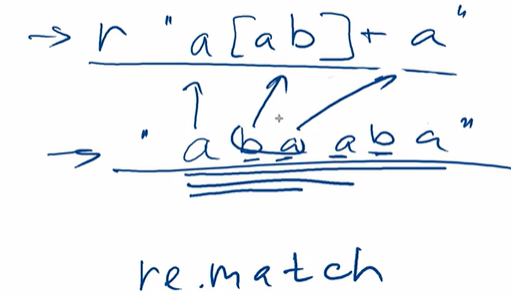

Регулярные выражения "жадные". Они берут самый длинный вариант строки.

In [54]:
import re
string="abc, acc, aac, ac, arc, adc, aBc, a8c, a&c, abbaba"
pattern=r'a[ab]+?a'
all_inclusions = re.findall(pattern, string)
print(all_inclusions)

['abba']


In [58]:
import re
string="test"
pattern=r"{test}*"
match = re.match(pattern, string)
print(match)

None


In [63]:
import re
string="testtext"
pattern=r"(test|text)*"
match = re.match(pattern, string)
print(match)

<re.Match object; span=(0, 8), match='testtext'>


In [67]:
import re
string="testtextabc"
pattern=r"((abc)|(test|text)*)"
match = re.match(pattern, string)
print(match)
print(match.groups())

<re.Match object; span=(0, 8), match='testtext'>
('testtext', None, 'text')


In [68]:
import re
string="abc"
pattern=r"((abc)|(test|text)*)"
match = re.match(pattern, string)
print(match)
print(match.groups())

<re.Match object; span=(0, 3), match='abc'>
('abc', 'abc', None)


In [76]:
import re
string="Hello abc"
pattern=r"Hello (abc|test)"
match = re.match(pattern, string)
print(match)
print(match.group())
print(match.group(0))
print(match.group(1))

<re.Match object; span=(0, 9), match='Hello abc'>
Hello abc
Hello abc
abc


In [78]:
import re
string="test-text"
pattern=r"(\w+)-\1"
match = re.match(pattern, string)
print(match)
print(match.group())
print(match.group(0))
print(match.group(1))

None


AttributeError: 'NoneType' object has no attribute 'group'

In [81]:
# put your python code here
import sys
import re

for line in sys.stdin:
    line = line.rstrip()

In [113]:
# put your python code here
import sys
import re
for line in sys.stdin:
    line = line.rstrip()
    if re.match(r'((?<!\S)cat(?!\S))|([^a-z\n ]cat[^a-z\n ])', line)!=None:
        print(line)
        

In [125]:
import sys
import re

for line in sys.stdin:
    line = line.rstrip()
    line=line.split(' ')
    l2=[]
    for i in line:
        z=list(i)
        x2=re.match(r'(?<=\b\w)\w',i)
        if x2==None:
            l2.append(i)
            continue
        x1=re.match(r'\b\w',i).pos
        x2=re.match(r'(?<=\b\w)\w',i).pos
        z[x1],z[x2]=z[x2],z[x1]
        l2.append(''.join(z))
    print(' '.join(l2))